# Gold & Silver Lease Curve Carry Strategy

## Strategy Overview

XAU and XAG **swap rates** represent the annualised cost of borrowing or lending physical metal against USD. They function as FX-swap analogues: a gold swap rate is the implied interest differential between holding metal and holding dollars for a given tenor.

A **steep** curve (front tenor rate elevated relative to back tenors) signals a short-term supply squeeze or convenience-yield dislocation — the market is paying a premium for near-term metal availability. Conversely, a flat or inverted curve suggests ample near-term supply.

### Trade Types

| Type | Description |
|---|---|
| **Slope Calendar** | Go long/short the rate differential between two adjacent tenors. Captures mean-reversion when the curve steepens or flattens abnormally. |
| **Butterfly** | Long belly vs short wings (or vice versa). Isolates curvature dislocations independent of parallel shifts. |
| **Cross-Metal RV** | Trade the spread between XAG and XAU swap rates at the same tenor. Captures relative supply/demand divergences between gold and silver. |

### Methodology

This notebook:
1. Constructs curve features (slopes, butterflies, cross-metal spreads) from raw swap rates.
2. Identifies rich/cheap dislocations via rolling z-scores.
3. Backtests mean-reversion and carry strategies across a parameter grid with IS/OOS validation.
4. Aggregates validated strategies into a risk-parity portfolio.

### Convention

All swap rates are in **annualised percentage terms**, using **ACT/360** day count convention:

$$F(T) = S \times \left(1 + r \times \frac{\text{actual\_days}}{360}\right)$$

where `actual_days` is the true calendar day count for the tenor (e.g. 365 for 1Y), and 360 is the fixed denominator.

In [1]:
# ============================================================
# CONFIG — All parameters in one place
# ============================================================

# --- Data ---
DATA_SOURCE   = 'csv'       # 'csv' or 'bql'
CSV_PATH      = 'data/data.csv'
SAVE_OUTPUTS  = True        # set False in BQNT

# --- Curve ---
METALS = ['xau', 'xag']
TENORS = ['1m', '3m', '6m', '9m', '1y', '2y']

# ACT/360: actual calendar days (numerator); 360 is always divisor
TENOR_DAYS = {
    '1m': 30,
    '3m': 91,
    '6m': 182,
    '9m': 273,
    '1y': 365,
    '2y': 730
}

ADJ_PAIRS = [
    ('1m','3m'), ('3m','6m'), ('6m','9m'), ('9m','1y'), ('1y','2y')
]

BUTTERFLY_TRIPLETS = [
    ('1m','3m','6m'),
    ('3m','6m','9m'),
    ('6m','9m','1y'),
    ('9m','1y','2y')
]

# XAG tenors with suspected Bloomberg ticker mismatch
XAG_EXCLUDE_TENORS = ['9m', '2y']

# --- Signal ---
ROLLING_WINDOW       = 252
MIN_PERIODS          = 126
VOL_WINDOW           = 20
HIGH_VOL_PCTILE      = 75
LOW_VOL_PCTILE       = 25
FUNDING_SHOCK_WINDOW = 5
FUNDING_SHOCK_MULT   = 1.5

# --- Backtest ---
ENTRY_Z_GRID    = [1.5, 2.0, 2.5]
EXIT_Z_GRID     = [0.0, 0.5]
STOP_Z          = 3.5
MAX_HOLD_GRID   = [20, 63, 126, 252]
# Autocorrelation analysis:
# lag=5d: ~0.85-0.91 (momentum), lag=63d: ~0.45, lag=252d: ~0.0
# Mean-reversion only manifests beyond 63-day holding period.

COST_BP_GRID = [0.04, 0.08, 0.12]
# Units: same as swap rates (annualised %).
# cost_bp deducted at entry AND exit; round-trip = 2 x cost_bp
# 0.04/leg = 8bp RT (LBMA typical), 0.08/leg = 16bp RT, 0.12/leg = 24bp RT

# ============================================================
# SOFR OIS Yield Curve Configuration
# ============================================================
OIS_TENORS = [
    'sofr_ois_1w',  'sofr_ois_2w',  'sofr_ois_1m',
    'sofr_ois_2m',  'sofr_ois_3m',  'sofr_ois_4m',
    'sofr_ois_5m',  'sofr_ois_6m',  'sofr_ois_7m',
    'sofr_ois_8m',  'sofr_ois_9m',  'sofr_ois_11m',
    'sofr_ois_1y',  'sofr_ois_2y'
]

OIS_DAYS = {
    'sofr_ois_1w':   7,  'sofr_ois_2w':  14,  'sofr_ois_1m':  30,
    'sofr_ois_2m':  61,  'sofr_ois_3m':  91,  'sofr_ois_4m': 122,
    'sofr_ois_5m': 152,  'sofr_ois_6m': 182,  'sofr_ois_7m': 213,
    'sofr_ois_8m': 243,  'sofr_ois_9m': 273,  'sofr_ois_11m': 334,
    'sofr_ois_1y': 365,  'sofr_ois_2y': 730
}

SWAP_OIS_MAP = {
    '1m': 'sofr_ois_1m',
    '3m': 'sofr_ois_3m',
    '6m': 'sofr_ois_6m',
    '9m': 'sofr_ois_9m',
    '1y': 'sofr_ois_1y',
    '2y': 'sofr_ois_2y'
}

FORWARD_SEGMENTS = [
    ('sofr_ois_1m',  'sofr_ois_3m',  30,  91),
    ('sofr_ois_3m',  'sofr_ois_6m',  91,  182),
    ('sofr_ois_6m',  'sofr_ois_9m',  182, 273),
    ('sofr_ois_9m',  'sofr_ois_1y',  273, 365),
    ('sofr_ois_1y',  'sofr_ois_2y',  365, 730)
]

INTRA_SEGMENTS = [
    ('sofr_ois_1w',  'sofr_ois_2w',   7,  14),
    ('sofr_ois_2w',  'sofr_ois_1m',  14,  30),
    ('sofr_ois_1m',  'sofr_ois_2m',  30,  61),
    ('sofr_ois_2m',  'sofr_ois_3m',  61,  91),
    ('sofr_ois_3m',  'sofr_ois_4m',  91, 122),
    ('sofr_ois_4m',  'sofr_ois_5m', 122, 152),
    ('sofr_ois_5m',  'sofr_ois_6m', 152, 182),
    ('sofr_ois_6m',  'sofr_ois_7m', 182, 213),
    ('sofr_ois_7m',  'sofr_ois_8m', 213, 243),
    ('sofr_ois_8m',  'sofr_ois_9m', 243, 273),
    ('sofr_ois_9m',  'sofr_ois_11m', 273, 334),
    ('sofr_ois_11m', 'sofr_ois_1y',  334, 365)
]

FUNDING_COL = 'sofr_ois_3m'

REGIME_ZIRP_MAX  = 0.50
REGIME_HIGH_MIN  = 3.50

SIZE_TYPE       = 'vol_target'
TARGET_VOL_BP   = 1.0
MAX_NOTIONAL    = 5.0
MIN_NOTIONAL    = 0.1

# --- IS/OOS split ---
IS_START  = '2018-01-01'
IS_END    = '2022-12-31'
OOS_START = '2023-01-01'
OOS_END   = '2026-02-22'

# --- Portfolio ---
CORR_THRESHOLD      = 0.60   # tightened: removes near-duplicate
                              # strategies with corr 0.60-0.99
REBAL_FREQ          = 'MS'
RISK_PARITY_WINDOW  = 63

# --- Validation criteria ---
MIN_OOS_SHARPE   = 0.5
MAX_DD_BLOWUP    = 3.0
MIN_IS_TRADES    = 3
MIN_OOS_TRADES   = 8  # raised: OOS is now 3+ years

# --- Monotonicity gate ---
USE_MONO_GATE = True   # set False to reproduce ungated baseline

print('CONFIG loaded.')

CONFIG loaded.


In [2]:
# ============================================================
# Imports
# ============================================================
import warnings
import itertools
import os

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

if SAVE_OUTPUTS:
    os.makedirs('outputs/charts', exist_ok=True)

print('Imports done.')

Imports done.


# 1. Data Ingestion

In [3]:
print('Section 1: Loading data...')

def load_data(source):
    """
    Load and standardise the input dataframe.
    source='csv': load from CSV_PATH
    source='bql': (BQNT) — see commented BQL template below
    Returns: df with DatetimeIndex, all original columns preserved.
    """
    if source == 'csv':
        df = pd.read_csv(CSV_PATH)
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').drop_duplicates('date')
        df = df.set_index('date')
        return df

    elif source == 'bql':
        # ============================================================
        # BQNT BQL TEMPLATE (uncomment and adapt when running in BQNT)
        # ============================================================
        # import bql
        # bq = bql.Service()
        #
        # For XAU swap rates by tenor, the Bloomberg field is typically:
        # XAUUSD_SWAP_RATE for each tenor (exact tickers TBC with your
        # Bloomberg subscription; common approach is to use
        # "XAU BGN Curncy" with FLDS=['PX_LAST'] per tenor)
        #
        # Example BQL structure:
        # universe = bq.univ.list([
        #   'XAU1M BGN Curncy', 'XAU3M BGN Curncy', 'XAU6M BGN Curncy',
        #   'XAU9M BGN Curncy', 'XAU1Y BGN Curncy', 'XAU2Y BGN Curncy',
        #   'XAG1M BGN Curncy', 'XAG3M BGN Curncy', 'XAG6M BGN Curncy',
        #   'XAG9M BGN Curncy', 'XAG1Y BGN Curncy', 'XAG2Y BGN Curncy',
        #   'SFR1 Comdty', 'SFR2 Comdty', 'SFR3 Comdty', 'SFR4 Comdty',
        # ])
        # data_item = bq.data.px_last(
        #   dates=bq.func.range('2020-01-01', '2025-01-01'),
        #   frq='D', fill='prev'
        # )
        # response = bq.execute(bql.Request(universe, data_item))
        # df = response[0].df()
        # ... reshape to match column naming convention ...
        # return df
        raise NotImplementedError("BQL source not yet implemented. "
                                  "See commented template above.")

# Execute
df = load_data(DATA_SOURCE)

# Data quality report
ffill_limit = 3
df = df.ffill(limit=ffill_limit)
# Funding proxy from OIS 3M (replaces old SOFR futures derivation)
df['funding_level'] = df['sofr_ois_3m']

missing_report = df.isna().sum()
missing_report = missing_report[missing_report > 0]
if len(missing_report) > 0:
    print("WARNING: Remaining NaN after forward-fill:")
    display(missing_report)
else:
    print(f"Data loaded: {len(df)} rows, {df.shape[1]} columns, "
          f"{df.index[0].date()} to {df.index[-1].date()}. No NaN.")

Section 1: Loading data...


gc_fut_front           1
gc_fut_second          1
gc_fut_third           1
xauusd_spot            1
si_fut_front           1
si_fut_second          1
si_fut_third           1
xagusd_spot            1
pl_fut_front           1
xptusd_spot            1
pa_fut_front           1
xpdusd_spot            1
hg_fut_front           1
lme_copper_3m          1
lme_zinc_3m            1
lme_nickel_3m          1
cl_fut_front           1
ng_fut_front           1
w_fut_front            1
c_fut_front            1
s_fut_front            1
shfe_au_front          1
shfe_au_second         1
tocom_au_front         3
lbma_gold_am           1
lbma_gold_pm           1
lbma_silver_fix        1
sofr_ois_1w            1
sofr_ois_2w            2
sofr_ois_2m            1
sofr_ois_7m            1
sofr_ois_8m            1
sofr_ois_10m           1
sofr_ois_11m           1
sofr_fut_front       123
sofr_fut_second      123
sofr_fut_third       123
sofr_fut_fourth      123
ust_2y_fut             1
ust_5y_fut             1


## 1b. OIS Yield Curve Bootstrap

In [4]:
print('Section 1b: Bootstrapping OIS yield curve...')

ois_cols = {}

# 1. Discount factors: P(0,T) = 1 / (1 + r_T/100 * T/360)
for tenor in OIS_TENORS:
    days = OIS_DAYS[tenor]
    ois_cols[f'ois_df_{tenor}'] = 1.0 / (1.0 + df[tenor] / 100.0 * days / 360.0)
    ois_cols[f'ois_zero_{tenor}'] = df[tenor]  # zero = spot rate for simple interest

# 2. Forward rates for FORWARD_SEGMENTS
for c1, c2, d1, d2 in FORWARD_SEGMENTS:
    t1_label = c1.replace('sofr_ois_', '')
    t2_label = c2.replace('sofr_ois_', '')
    df_t1 = ois_cols[f'ois_df_{c1}']
    df_t2 = ois_cols[f'ois_df_{c2}']
    ois_cols[f'ois_fwd_{t1_label}_{t2_label}'] = (
        (df_t1 / df_t2 - 1.0) * 360.0 / (d2 - d1) * 100
    )

# 3. Intra-segment forward rates
for c1, c2, d1, d2 in INTRA_SEGMENTS:
    t1_label = c1.replace('sofr_ois_', '')
    t2_label = c2.replace('sofr_ois_', '')
    df_t1 = ois_cols[f'ois_df_{c1}']
    df_t2 = ois_cols[f'ois_df_{c2}']
    ois_cols[f'ois_intra_fwd_{t1_label}_{t2_label}'] = (
        (df_t1 / df_t2 - 1.0) * 360.0 / (d2 - d1) * 100
    )

# 4. OIS forward curve slopes
fwd_labels = []
for c1, c2, d1, d2 in FORWARD_SEGMENTS:
    fwd_labels.append((c1.replace('sofr_ois_',''), c2.replace('sofr_ois_','')))

for i in range(len(fwd_labels) - 1):
    t1a, t1b = fwd_labels[i]
    t2a, t2b = fwd_labels[i+1]
    ois_cols[f'ois_fwd_slope_{t1a}_{t1b}_{t2a}_{t2b}'] = (
        ois_cols[f'ois_fwd_{t2a}_{t2b}'] - ois_cols[f'ois_fwd_{t1a}_{t1b}']
    )

# Concat all OIS columns
df = pd.concat([df, pd.DataFrame(ois_cols, index=df.index)], axis=1)
df = df.copy()

# 5. Rate regime
df['rate_regime'] = np.where(
    df[FUNDING_COL] < REGIME_ZIRP_MAX, 'zirp',
    np.where(df[FUNDING_COL] >= REGIME_HIGH_MIN, 'high', 'mid'))

# 6. OIS curve inversion metric
df['ois_curve_inversion'] = df['ois_fwd_1m_3m'] - df['ois_fwd_9m_1y']

# 7. Quality report
last = df.iloc[-1]
last_date = df.index[-1]
print(f"\n=== OIS DISCOUNT CURVE ({last_date.date()}) ===")
print(f"{'Tenor':<14s} {'Days':>5s} {'OIS%':>8s} {'DF':>10s} {'Zero%':>8s}")
for tenor in OIS_TENORS:
    days = OIS_DAYS[tenor]
    label = tenor.replace('sofr_ois_','')
    ois_pct = last[tenor]
    df_val = last[f'ois_df_{tenor}']
    zero_pct = last[f'ois_zero_{tenor}']
    print(f"{label:<14s} {days:>5d} {ois_pct:>8.3f} {df_val:>10.6f} {zero_pct:>8.3f}")

print(f"\n=== OIS FORWARD CURVE ({last_date.date()}) ===")
print(f"{'Segment':<16s} {'FwdDays':>8s} {'Fwd%':>8s}")
for c1, c2, d1, d2 in FORWARD_SEGMENTS:
    t1 = c1.replace('sofr_ois_','')
    t2 = c2.replace('sofr_ois_','')
    fwd = last[f'ois_fwd_{t1}_{t2}']
    print(f"{t1}\u2192{t2:<10s} {d2-d1:>5d}d {fwd:>8.3f}")

print(f"\n=== RATE REGIME DISTRIBUTION ===")
regime_counts = df['rate_regime'].value_counts()
for regime in ['zirp','mid','high']:
    cnt = regime_counts.get(regime, 0)
    pct = cnt / len(df) * 100
    print(f"  {regime:<6s}: {cnt:>5d} rows ({pct:.1f}%)")

# Non-monotone discount curve check (row-level flag)
df['non_monotone_flag'] = False
for i in range(len(OIS_TENORS) - 1):
    t1, t2 = OIS_TENORS[i], OIS_TENORS[i+1]
    df['non_monotone_flag'] |= df[f'ois_df_{t2}'] > df[f'ois_df_{t1}']
df['curve_monotone'] = ~df['non_monotone_flag']
non_mono_days = int(df['non_monotone_flag'].sum())
if non_mono_days > 0:
    print(f"\nWARNING: {non_mono_days} non-monotone discount curve days detected")
else:
    print("\nDiscount curve monotonicity: OK (no negative forward rates)")

# --- Per-segment monotonicity flag ---
# For each FORWARD_SEGMENT, True = discount factor strictly decreasing (normal)
print("\n=== PER-SEGMENT MONOTONICITY ===")
for c1, c2, d1, d2 in FORWARD_SEGMENTS:
    flag_col = (f'mono_{c1.replace("sofr_ois_","")}_'
               f'{c2.replace("sofr_ois_","")}')
    df[flag_col] = df[f'ois_df_{c1}'] > df[f'ois_df_{c2}']
    n_viol = (~df[flag_col]).sum()
    if n_viol > 0:
        bad_idx = df[~df[flag_col]].index
        print(f'  {flag_col}: {n_viol} non-monotone days '
              f'({bad_idx[0].date()} to {bad_idx[-1].date()})')
    else:
        print(f'  {flag_col}: monotone on all days \u2713')

# Global: all segments monotone
mono_seg_cols = [
    f'mono_{c1.replace("sofr_ois_","")}_'
    f'{c2.replace("sofr_ois_","")}'
    for c1, c2, d1, d2 in FORWARD_SEGMENTS
]
df['ois_curve_fully_monotone'] = df[mono_seg_cols].all(axis=1)
n_global_viol = (~df['ois_curve_fully_monotone']).sum()
print(f'\n  Global (all segments): '
      f'{n_global_viol} days with ANY non-monotone segment')

# Date sets for backtest gate
NON_MONO_DATES = set(df[~df['ois_curve_fully_monotone']].index)
NON_MONO_DATES_BY_SEG = {}
for c1, c2, d1, d2 in FORWARD_SEGMENTS:
    t1 = c1.replace('sofr_ois_', '')
    t2 = c2.replace('sofr_ois_', '')
    flag_col = f'mono_{t1}_{t2}'
    NON_MONO_DATES_BY_SEG[f'{t1}_{t2}'] = set(df[~df[flag_col]].index)

if SAVE_OUTPUTS:
    df.reset_index().to_csv('outputs/01b_ois_curve.csv', index=False)

Section 1b: Bootstrapping OIS yield curve...

=== OIS DISCOUNT CURVE (2026-02-22) ===
Tenor           Days     OIS%         DF    Zero%
1w                 7    3.686   0.999284    3.686
2w                14    3.674   0.998573    3.674
1m                30    3.674   0.996948    3.674
2m                61    3.676   0.993809    3.676
3m                91    3.671   0.990806    3.671
4m               122    3.665   0.987732    3.665
5m               152    3.648   0.984832    3.648
6m               182    3.625   0.982005    3.625
7m               213    3.603   0.979127    3.603
8m               243    3.574   0.976446    3.574
9m               273    3.546   0.973816    3.546
11m              334    3.492   0.968617    3.492
1y               365    3.470   0.966015    3.470
2y               730    3.298   0.937310    3.298

=== OIS FORWARD CURVE (2026-02-22) ===
Segment           FwdDays     Fwd%
1m→3m            61d    3.659
3m→6m            91d    3.545
6m→9m            91d    3.327

# 2. Curve Feature Construction

## ACT/360 Forward Price Reference

The forward price for tenor $T$ is:

$$F(T) = S \times \left(1 + r \times \frac{\text{actual\_days}}{360}\right)$$

where `actual_days = TENOR_DAYS[T]` uses the **true calendar day count** as the numerator, and **360 is always the fixed denominator**.

For 1Y: `actual_days = 365`, so $F(1Y) = S \times (1 + r \times 365/360)$. Using 360 as the numerator here would understate the forward by ~1.4%.

**Feature definitions:**

- **Slope** = $q(T_1) - q(T_2)$: positive means the front tenor is "rich" relative to the back.
- **Butterfly** = $q(T_2) - 0.5 \times (q(T_1) + q(T_3))$: positive means the belly is rich.
- **Roll-down** approximation: the annualised carry earned if the curve is unchanged and the position rolls from $T_2$ towards $T_1$ over the $T_1$ holding period.

In [5]:
print('Section 2: Building lease rate features...')

feature_cols = []
feat_counts = {'xau_lease_slope':0, 'xag_lease_slope':0,
               'xau_fwd_lease':0, 'xag_fwd_lease':0,
               'xm_spread':0, 'butterfly':0}

# --- BLOCK A: Spot Lease Rates ---
# Lease rate = OIS - Metal Swap (positive = metal scarce)
for metal in METALS:
    for t in TENORS:
        ois_col = SWAP_OIS_MAP[t]
        df[f'{metal}_lease_{t}'] = df[ois_col] - df[f'{metal}_swap_{t}']

# Data quality check: flag anomalous tenors
FLAGGED_COLS = []
for metal in METALS:
    tenor_means = {t: df[f'{metal}_lease_{t}'].mean() for t in TENORS}
    median_mean = np.median(list(tenor_means.values()))
    for t, m in tenor_means.items():
        if median_mean != 0 and abs(m - median_mean) / abs(median_mean) > 0.50:
            col_name = f'{metal}_lease_{t}'
            FLAGGED_COLS.append(col_name)
            print(f"  WARNING: {col_name} ANOMALOUS: mean={m:.3f}% "
                  f"vs median={median_mean:.3f}%")

# Also flag based on known XAG issues
for t in XAG_EXCLUDE_TENORS:
    fc = f'xag_lease_{t}'
    if fc not in FLAGGED_COLS:
        FLAGGED_COLS.append(fc)
        print(f"  FLAGGED (config): {fc}")

if FLAGGED_COLS:
    print(f"Flagged columns (excluded from features): {FLAGGED_COLS}")

# --- BLOCK B: Lease Rate Slopes (Adjacent Tenors) ---
for metal in METALS:
    for t1, t2 in ADJ_PAIRS:
        if f'{metal}_lease_{t1}' in FLAGGED_COLS or f'{metal}_lease_{t2}' in FLAGGED_COLS:
            continue
        col = f'{metal}_lease_slope_{t1}_{t2}'
        df[col] = df[f'{metal}_lease_{t1}'] - df[f'{metal}_lease_{t2}']
        feature_cols.append(col)
        feat_counts[f'{metal}_lease_slope'] += 1

# --- BLOCK C: OIS-Stripped Forward Lease Rates (XAU only) ---
for c1, c2, d1, d2 in FORWARD_SEGMENTS:
    t1_label = c1.replace('sofr_ois_', '')
    t2_label = c2.replace('sofr_ois_', '')
    # Check both XAU swap tenors exist
    if f'xau_swap_{t1_label}' not in df.columns or f'xau_swap_{t2_label}' not in df.columns:
        continue
    # Metal discount factors from swap rates
    P_metal_t1 = 1.0 / (1.0 + df[f'xau_swap_{t1_label}'] / 100.0 * d1 / 360.0)
    P_metal_t2 = 1.0 / (1.0 + df[f'xau_swap_{t2_label}'] / 100.0 * d2 / 360.0)
    xau_fwd = (P_metal_t1 / P_metal_t2 - 1.0) * 360.0 / (d2 - d1) * 100
    col = f'xau_fwd_lease_{t1_label}_{t2_label}'
    df[col] = df[f'ois_fwd_{t1_label}_{t2_label}'] - xau_fwd
    feature_cols.append(col)
    feat_counts['xau_fwd_lease'] += 1

# --- BLOCK C2: XAG Forward Lease Rates (1m→3m and 3m→6m only) ---
# Clean XAG tenors: 1m, 3m, 6m only (9m and 2y are flagged)
XAG_CLEAN_FWD_PAIRS = [
    ('sofr_ois_1m', 'sofr_ois_3m',  30,  91),   # 1m→3m
    ('sofr_ois_3m', 'sofr_ois_6m',  91, 182),   # 3m→6m
]

for c1, c2, d1, d2 in XAG_CLEAN_FWD_PAIRS:
    t1_label = c1.replace('sofr_ois_', '')
    t2_label = c2.replace('sofr_ois_', '')

    # XAG metal discount factors
    P_xag_t1 = 1.0 / (1.0 + df[f'xag_swap_{t1_label}'] / 100.0 * d1 / 360.0)
    P_xag_t2 = 1.0 / (1.0 + df[f'xag_swap_{t2_label}'] / 100.0 * d2 / 360.0)
    xag_fwd  = (P_xag_t1 / P_xag_t2 - 1.0) * 360.0 / (d2 - d1) * 100

    col = f'xag_fwd_lease_{t1_label}_{t2_label}'
    df[col] = df[f'ois_fwd_{t1_label}_{t2_label}'] - xag_fwd

    # Data quality gate — same anomaly check as spot lease rates
    col_mean   = df[col].mean()
    col_median = df[col].median()
    if col_median != 0 and abs(col_mean - col_median) / abs(col_median) > 0.50:
        FLAGGED_COLS.append(col)
        print(f'  WARNING: {col} ANOMALOUS: '
              f'mean={col_mean:.3f}% vs median={col_median:.3f}%')
    else:
        feature_cols.append(col)
        feat_counts['xag_fwd_lease'] = feat_counts.get('xag_fwd_lease', 0) + 1
        print(f'  {col}: mean={col_mean:.3f}%  median={col_median:.3f}%  ✓')

# --- BLOCK D: Cross-Metal Lease Spread ---
for t in TENORS:
    if f'xag_lease_{t}' in FLAGGED_COLS:
        continue
    col = f'xm_lease_spread_{t}'
    df[col] = df[f'xag_lease_{t}'] - df[f'xau_lease_{t}']
    feature_cols.append(col)
    feat_counts['xm_spread'] += 1

# --- BLOCK E: Lease Rate Butterflies (XAU) ---
for t1, t2, t3 in BUTTERFLY_TRIPLETS:
    if any(f'xau_lease_{t}' in FLAGGED_COLS for t in [t1, t2, t3]):
        continue
    col = f'xau_lease_bfly_{t1}_{t2}_{t3}'
    df[col] = df[f'xau_lease_{t1}'] - 2*df[f'xau_lease_{t2}'] + df[f'xau_lease_{t3}']
    feature_cols.append(col)
    feat_counts['butterfly'] += 1

# --- BLOCK F: OIS Forward Curve Slope as Macro Overlay ---
df['ois_fwd_slope_front'] = df['ois_fwd_1m_3m'] - df['ois_intra_fwd_1w_2w']
df['ois_fwd_slope_belly'] = df['ois_fwd_3m_6m'] - df['ois_fwd_1m_3m']
df['ois_fwd_slope_back']  = df['ois_fwd_6m_9m'] - df['ois_fwd_3m_6m']

# --- Roll-down approximation (ACT/360) for slopes ---
for metal in METALS:
    for t1, t2 in ADJ_PAIRS:
        slope_col = f'{metal}_lease_slope_{t1}_{t2}'
        if slope_col not in df.columns:
            continue
        d1 = TENOR_DAYS[t1]
        d2 = TENOR_DAYS[t2]
        df[f'{metal}_rolldown_{t1}'] = df[slope_col] * (d1 / (d2 - d1))

if SAVE_OUTPUTS:
    df.reset_index().to_csv('outputs/02_lease_features.csv', index=False)

print(f"\nFeatures constructed: {len(feature_cols)} total")
for k, v in feat_counts.items():
    print(f"  - {k}: {v}")
print(f"  - Flagged/excluded: {FLAGGED_COLS}")

Section 2: Building lease rate features...
Flagged columns (excluded from features): ['xau_lease_2y', 'xag_lease_9m', 'xag_lease_2y']



Features constructed: 18 total
  - xau_lease_slope: 4
  - xag_lease_slope: 2
  - xau_fwd_lease: 5
  - xag_fwd_lease: 0
  - xm_spread: 4
  - butterfly: 3
  - Flagged/excluded: ['xau_lease_2y', 'xag_lease_9m', 'xag_lease_2y', 'xag_fwd_lease_1m_3m', 'xag_fwd_lease_3m_6m']


## 2b. Slope Persistence Analysis

Section 2b: Autocorrelation profile...
Autocorrelation by lag (slope features):


,lag_1d,lag_5d,lag_10d,lag_20d,lag_63d,lag_126d,lag_252d
xau_lease_slope_1m_3m,0.7360,0.6200,0.5320,0.3440,0.0590,-0.0500,-0.0020
xau_lease_slope_3m_6m,0.8040,0.6560,0.4710,0.1340,0.0570,0.0240,-0.0500
xau_lease_slope_6m_9m,0.7000,0.5740,0.4950,0.3550,0.1150,-0.0770,-0.0390
xau_lease_slope_9m_1y,0.1540,0.0900,0.0750,0.0360,0.1730,0.0280,0.0050
xag_lease_slope_1m_3m,0.8410,0.5480,0.3550,-0.0580,0.0050,-0.0540,0.0670
xag_lease_slope_3m_6m,0.8700,0.5590,0.4080,0.1270,0.0930,-0.0120,0.1370


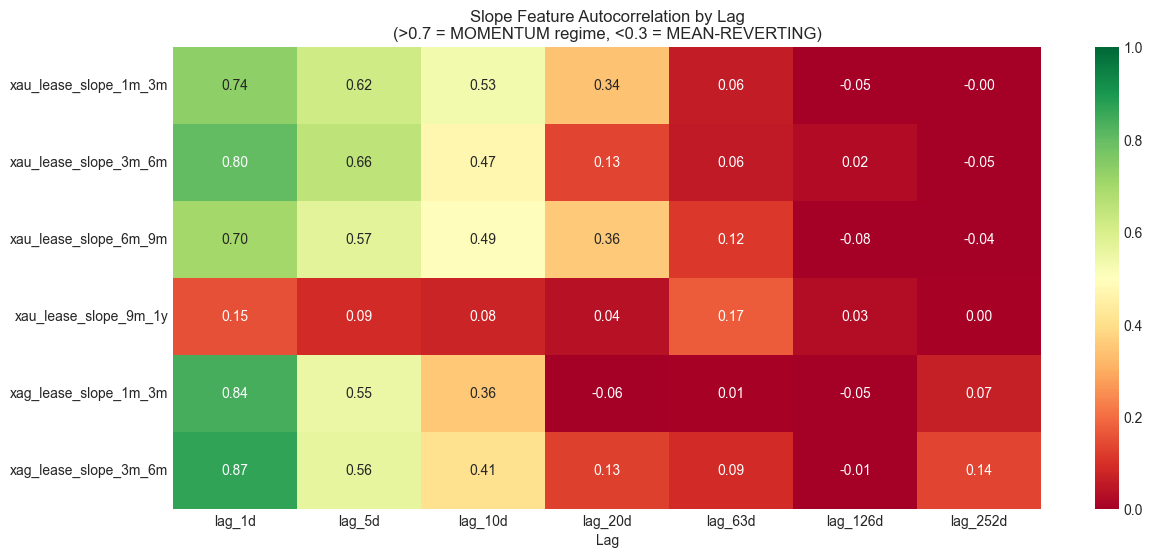

Autocorrelation analysis complete.


In [6]:
print('Section 2b: Autocorrelation profile...')

acf_lags = [1, 5, 10, 20, 63, 126, 252]
acf_data = {}

# Only clean slope features (exclude corrupted XAG tenors)
clean_slope_cols = [c for c in feature_cols
                    if '_slope_' in c]

for col in clean_slope_cols:
    series = df[col].dropna()
    acf_data[col] = {lag: series.autocorr(lag=lag) for lag in acf_lags
                     if lag < len(series)}

# XAG forward lease ACF (features that passed quality gate)
xag_fwd_cols = [c for c in feature_cols if 'xag_fwd_lease' in c]
for col in xag_fwd_cols:
    series = df[col].dropna()
    acf_data[col] = {lag: series.autocorr(lag=lag) for lag in acf_lags
                     if lag < len(series)}

acf_df = pd.DataFrame(acf_data).T
acf_df.columns = [f'lag_{l}d' for l in acf_lags[:len(acf_df.columns)]]

# Label regime
def label_regime(val):
    if pd.isna(val):
        return ''
    if val > 0.7:
        return 'MOMENTUM'
    elif val < 0.3:
        return 'MEAN-REV'
    return ''

print("Autocorrelation by lag (slope features):")
display(acf_df.round(3))

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(acf_df.astype(float), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0.5, vmin=0, vmax=1, ax=ax,
            yticklabels=True)
ax.set_title('Slope Feature Autocorrelation by Lag\n'
             '(>0.7 = MOMENTUM regime, <0.3 = MEAN-REVERTING)')
ax.set_xlabel('Lag')

if SAVE_OUTPUTS:
    plt.savefig('outputs/charts/00_autocorrelation_profile.png',
                dpi=150, bbox_inches='tight')
    acf_df.to_csv('outputs/00_autocorrelation.csv')
plt.show(); plt.close()

print("Autocorrelation analysis complete.")

# 3. Signal Construction (Rich/Cheap Framework)

In [7]:
print('Section 3: Constructing signals...')

new_cols = {}

for col in feature_cols:
    roll = df[col].rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS)
    rv   = df[col].rolling(VOL_WINDOW).std()
    rv_rl = rv.rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS)

    new_cols[f'z_{col}']       = (df[col] - roll.mean()) / roll.std()
    new_cols[f'z_fast_{col}']  = (
        (df[col] - df[col].rolling(126, min_periods=63).mean())
        / df[col].rolling(126, min_periods=63).std()
    )
    new_cols[f'rv_{col}']      = rv
    new_cols[f'pctile_{col}']  = df[col].rolling(
        ROLLING_WINDOW, min_periods=MIN_PERIODS
    ).rank(pct=True) * 100
    new_cols[f'highvol_{col}'] = (rv > rv_rl.quantile(HIGH_VOL_PCTILE / 100)).fillna(False)
    new_cols[f'lowvol_{col}']  = (rv < rv_rl.quantile(LOW_VOL_PCTILE / 100)).fillna(False)

# Funding shock (using OIS 3M)
fund_chg = df[FUNDING_COL].diff(FUNDING_SHOCK_WINDOW)
fund_std = fund_chg.rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).std()
new_cols['funding_shock'] = (fund_chg.abs() > FUNDING_SHOCK_MULT * fund_std).fillna(False)

# Curve inversion flag
new_cols['curve_inverted'] = df['ois_curve_inversion'] < -0.10

# Gold vol regime
new_cols['gold_vol_high'] = df['gold_vol_index'] > 25.0

# SHFE premium
shfe_prem = (df['shfe_au_front'] * 31.1035 / df['usdcnh_spot']) / df['gc_fut_front'] - 1
shfe_prem = shfe_prem * 100
new_cols['shfe_premium'] = shfe_prem
shfe_roll = shfe_prem.rolling(252, min_periods=126)
new_cols['shfe_premium_z'] = (shfe_prem - shfe_roll.mean()) / shfe_roll.std()

df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)
df = df.copy()  # defragment

zscore_cols = [f'z_{c}' for c in feature_cols]
pctile_cols = [f'pctile_{c}' for c in feature_cols]

if SAVE_OUTPUTS:
    df.reset_index().to_csv('outputs/03_signals.csv', index=False)
print(f"Signals constructed: {len(feature_cols)} features, "
      f"{len(zscore_cols)} z-scores, z_fast + rv + regime flags.")

Section 3: Constructing signals...


Signals constructed: 18 features, 18 z-scores, z_fast + rv + regime flags.


# 4. Single-Strategy Backtesting Engine

In [8]:
print('Section 4: Defining backtest engine...')

def backtest_single(df, signal_col, feature_col,
                    entry_z=2.0, exit_z=0.5,
                    stop_z=3.5, max_hold=63,
                    cost_bp=0.04,
                    use_fast_z=False,
                    curve_inversion_filter=False,
                    curve_monotone_filter=False,
                    gold_vol_boost=False,
                    mono_gate=True,
                    non_mono_dates=None):
    """
    mono_gate: if True, block new entries on days where the OIS
               discount curve is non-monotone (artefact forward rates).
    non_mono_dates: explicit set of pd.Timestamps to exclude from entry.
                    If None and mono_gate=True, uses global NON_MONO_DATES.
    """
    """
    State machine backtest for one lease rate feature / signal pair.

    States: 0=FLAT, -1=SHORT lease (z was +ve, fade), +1=LONG lease (z was -ve, fade)
    P&L = mark-to-market + carry accrual - costs (all in annualised % units)
    """
    z    = df[signal_col].values
    feat = df[feature_col].values
    rv   = df[f'rv_{feature_col}'].values
    fs   = df['funding_shock'].values
    hv   = df[f'highvol_{feature_col}'].values
    lv   = df[f'lowvol_{feature_col}'].values
    gvh  = df['gold_vol_high'].values
    ci   = df['curve_inverted'].values

    z_fast_col = f'z_fast_{feature_col}'
    z_fast = df[z_fast_col].values if z_fast_col in df.columns else None
    rate_regime_arr = df['rate_regime'].values if 'rate_regime' in df.columns else None
    cm = (df['curve_monotone'].values
          if (curve_monotone_filter and 'curve_monotone' in df.columns) else None)

    # Monotonicity gate: resolve non_mono_dates set once before the loop
    dates = df.index
    try:
        _non_mono_global = NON_MONO_DATES if mono_gate else set()
    except NameError:
        _non_mono_global = set()
    _non_mono = non_mono_dates if non_mono_dates is not None else _non_mono_global

    pos   = np.zeros(len(df))
    pnl   = np.zeros(len(df))
    carry = np.zeros(len(df))
    state = 0; days_held = 0; notional = 0.0
    entry_i = None; entry_z_ = None; entry_f_ = None
    trades = []

    for i in range(1, len(df)):
        if np.isnan(z[i]):
            continue

        df_feat = feat[i] - feat[i-1]

        eff_entry_z = (entry_z * 0.75
                       if (gold_vol_boost and not np.isnan(gvh[i]) and gvh[i])
                       else entry_z)

        if state == 0:
            enter = (abs(z[i]) >= eff_entry_z
                     and not fs[i]
                     and not (curve_inversion_filter and ci[i])
                     and not (curve_monotone_filter and cm is not None and not cm[i])
                     and not (mono_gate and dates[i] in _non_mono))
            use_fast_here = (
                use_fast_z or
                (rate_regime_arr is not None and rate_regime_arr[i] == 'high'))
            if use_fast_here and z_fast is not None and not np.isnan(z_fast[i]):
                enter = enter and abs(z_fast[i]) >= eff_entry_z * 0.8
            if enter:
                state     = -int(np.sign(z[i]))
                days_held = 0
                entry_i   = i; entry_z_ = z[i]; entry_f_ = feat[i]
                vol_est   = max(rv[i] if not np.isnan(rv[i]) else TARGET_VOL_BP, 0.01)
                raw_not   = TARGET_VOL_BP / vol_est
                if gold_vol_boost and not np.isnan(gvh[i]) and gvh[i]:
                    mult = 1.50
                elif not np.isnan(hv[i]) and hv[i]:
                    mult = 0.75
                elif not np.isnan(lv[i]) and lv[i]:
                    mult = 1.25
                else:
                    mult = 1.0
                notional = float(np.clip(raw_not * mult, MIN_NOTIONAL, MAX_NOTIONAL))
                pos[i]   = state * notional
                pnl[i]  -= cost_bp
        else:
            days_held += 1
            converged = (state == +1 and z[i] >= -exit_z) or \
                        (state == -1 and z[i] <=  exit_z)
            stopped   = (state == +1 and z[i] <= -stop_z) or \
                        (state == -1 and z[i] >=  stop_z)
            timed_out = days_held >= max_hold

            pos[i]   = state * notional
            pnl[i]   = pos[i-1] * df_feat
            carry[i] = pos[i-1] * feat[i] / 360.0  # notional-weighted
            pnl[i]  += carry[i]

            if converged or stopped or timed_out:
                pnl[i] -= cost_bp
                exit_reason = ('convergence' if converged else
                               'stop_z' if stopped else 'time')
                trades.append({
                    'entry_date'   : df.index[entry_i],
                    'exit_date'    : df.index[i],
                    'entry_z'      : entry_z_,
                    'exit_z'       : z[i],
                    'entry_feature': entry_f_,
                    'exit_feature' : feat[i],
                    'pnl_bp'       : pnl[entry_i:i+1].sum(),
                    'carry_bp'     : carry[entry_i:i+1].sum(),
                    'mrv_bp'       : pnl[entry_i:i+1].sum() - carry[entry_i:i+1].sum(),
                    'days_held'    : days_held,
                    'exit_reason'  : exit_reason,
                    'notional'     : notional,
                    'rate_regime'  : df['rate_regime'].iloc[entry_i]
                })
                state = 0; days_held = 0; notional = 0.0
            if state == 0:
                pos[i] = 0.0

    trade_log = pd.DataFrame(trades)
    daily = pd.DataFrame({
        'date': df.index, 'position': pos,
        'pnl_bp': pnl, 'carry_bp': carry,
        'cum_pnl_bp': np.cumsum(pnl)
    }).set_index('date')

    cum     = np.cumsum(pnl)
    dd      = cum - np.maximum.accumulate(cum)
    ann_ret = pnl.mean() * 252
    ann_vol = pnl.std() * np.sqrt(252)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    max_dd  = float(dd.min())
    calmar  = ann_ret / abs(max_dd) if max_dd != 0 else np.nan

    if len(trade_log):
        hit_rate   = float(trade_log['pnl_bp'].gt(0).mean())
        by_reason  = trade_log['exit_reason'].value_counts(normalize=True).to_dict()
        by_regime  = trade_log.groupby('rate_regime')['pnl_bp'].mean().to_dict()
        carry_frac = float(carry.sum() / cum[-1]) if cum[-1] != 0 else np.nan
    else:
        hit_rate = np.nan; by_reason = {}; by_regime = {}; carry_frac = np.nan

    metrics = {
        'total_pnl_bp' : float(cum[-1]) if len(cum) > 0 else 0.0,
        'total_carry_bp': float(carry.sum()),
        'total_mrv_bp' : float(cum[-1]) - float(carry.sum()) if len(cum) > 0 else 0.0,
        'carry_frac'   : carry_frac,
        'ann_sharpe'   : sharpe,
        'hit_rate'     : hit_rate,
        'avg_hold_days': float(trade_log['days_held'].mean()) if len(trade_log) else np.nan,
        'avg_pnl_trade': float(trade_log['pnl_bp'].mean()) if len(trade_log) else np.nan,
        'max_dd_bp'    : max_dd,
        'calmar'       : calmar,
        'pct_in_market': float((pos != 0).mean()),
        'num_trades'   : len(trade_log),
        'exit_by_reason': by_reason,
        'pnl_by_regime': by_regime
    }
    return {'trade_log': trade_log, 'daily': daily, 'metrics': metrics}

print("backtest_single() defined.")

Section 4: Defining backtest engine...
backtest_single() defined.


## 4b. Cost Sensitivity Analysis

Section 4b: Cost sensitivity analysis...
Top 3 buckets: ['xau_fwd_lease_1y_2y', 'xag_lease_slope_3m_6m', 'xau_lease_bfly_6m_9m_1y']


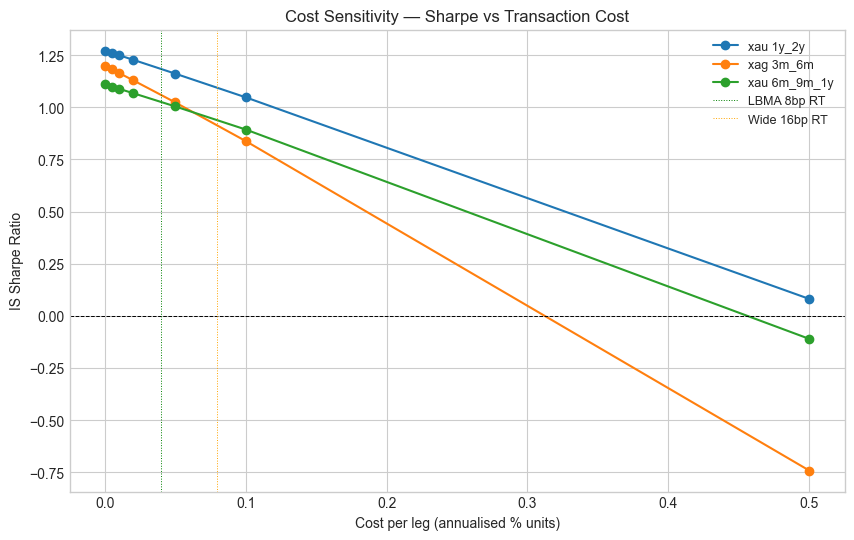

Cost sensitivity analysis complete.


In [9]:
print('Section 4b: Cost sensitivity analysis...')

# Build local strategy list from feature_cols
_scan_defs = []
for col in feature_cols:
    if 'fwd_lease' in col:
        ftype = 'fwd_lease'
    elif 'bfly' in col:
        ftype = 'butterfly'
    elif 'xm_lease' in col:
        ftype = 'xm_spread'
    elif 'slope' in col:
        ftype = 'slope'
    else:
        ftype = 'other'
    metal = col.split('_')[0] if not col.startswith('xm') else 'xm'
    bucket = col.replace(f'{metal}_lease_slope_','').replace(f'{metal}_fwd_lease_','').replace(f'xm_lease_spread_','').replace(f'{metal}_lease_bfly_','')
    _scan_defs.append({
        'metal': metal, 'feature_type': ftype, 'bucket': bucket,
        'feature_col': col, 'signal_col': f'z_{col}'
    })

scan_results = []
for sdef in _scan_defs:
    r = backtest_single(
        df.loc[IS_START:IS_END],
        sdef['signal_col'], sdef['feature_col'],
        entry_z=2.0, exit_z=0.5, stop_z=STOP_Z,
        max_hold=63, cost_bp=0.04)
    scan_results.append({
        **sdef,
        'abs_sharpe': abs(r['metrics']['ann_sharpe'])
                      if not np.isnan(r['metrics']['ann_sharpe']) else 0
    })

scan_df = pd.DataFrame(scan_results).nlargest(3, 'abs_sharpe')
print(f"Top 3 buckets: {list(scan_df['feature_col'].values)}")

cost_test_grid = [0, 0.005, 0.010, 0.020, 0.050, 0.100, 0.500]

fig, ax = plt.subplots(figsize=(10, 6))
for _, srow in scan_df.iterrows():
    sharpes = []
    for c in cost_test_grid:
        r = backtest_single(
            df.loc[IS_START:IS_END],
            srow['signal_col'], srow['feature_col'],
            entry_z=2.0, exit_z=0.5, stop_z=STOP_Z,
            max_hold=63, cost_bp=c)
        sharpes.append(r['metrics']['ann_sharpe'])
    ax.plot(cost_test_grid, sharpes, 'o-',
            label=f"{srow['metal']} {srow['bucket']}", linewidth=1.5)

ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax.axvline(0.04, color='green', linewidth=0.7, linestyle=':', label='LBMA 8bp RT')
ax.axvline(0.08, color='orange', linewidth=0.7, linestyle=':', label='Wide 16bp RT')
ax.set_xlabel('Cost per leg (annualised % units)')
ax.set_ylabel('IS Sharpe Ratio')
ax.set_title('Cost Sensitivity — Sharpe vs Transaction Cost')
ax.legend(fontsize=9)
if SAVE_OUTPUTS:
    plt.savefig('outputs/charts/00b_cost_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("Cost sensitivity analysis complete.")

# --- Monotonicity Gate Sensitivity ---
_scan_top3 = list(scan_df['feature_col'].values)
_df_is = df.loc[IS_START:IS_END]

print("\n--- Monotonicity Gate Sensitivity ---")
print("Comparing ungated vs gated (global) vs gated (per-segment)")
print(f"{'Strategy':<35} {'Ungated SR':>12} "
      f"{'Global gate SR':>15} {'Seg gate SR':>12}")

for col in _scan_top3:
    zcol = f'z_{col}'
    if zcol not in df.columns:
        continue

    # Find the most specific matching segment
    seg_key = None
    for seg in NON_MONO_DATES_BY_SEG:
        if seg.replace('_', '') in col.replace('_', ''):
            seg_key = seg; break

    r_ungated = backtest_single(
        _df_is, zcol, col,
        entry_z=1.5, exit_z=0.5, max_hold=63,
        cost_bp=0.04, mono_gate=False
    )
    r_global = backtest_single(
        _df_is, zcol, col,
        entry_z=1.5, exit_z=0.5, max_hold=63,
        cost_bp=0.04, mono_gate=True,
        non_mono_dates=NON_MONO_DATES
    )
    r_seg = backtest_single(
        _df_is, zcol, col,
        entry_z=1.5, exit_z=0.5, max_hold=63,
        cost_bp=0.04, mono_gate=True,
        non_mono_dates=(
            NON_MONO_DATES_BY_SEG.get(seg_key, set())
            if seg_key else NON_MONO_DATES
        )
    )
    sr_u = r_ungated['metrics']['ann_sharpe']
    sr_g = r_global['metrics']['ann_sharpe']
    sr_s = r_seg['metrics']['ann_sharpe']
    flag = (' \u26a0 ARTEFACT?'
            if (not np.isnan(sr_u) and not np.isnan(sr_g)
                and sr_u - sr_g > 0.30)
            else ' \u2713')
    sr_u_s = f'{sr_u:>10.4f}' if not np.isnan(sr_u) else f'{'nan':>10}'
    sr_g_s = f'{sr_g:>12.4f}' if not np.isnan(sr_g) else f'{'nan':>12}'
    sr_s_s = f'{sr_s:>10.4f}' if not np.isnan(sr_s) else f'{'nan':>10}'
    print(f'  {col:<35} {sr_u_s}   {sr_g_s}   {sr_s_s}{flag}')

print()
print('Interpretation:')
print('  Drop > 0.30 SR = non-monotone days contributed materially')
print('  \u2192 apply per-segment gate in production')
print('  Drop < 0.10 SR = alpha robust to OIS artefacts \u2713')

# 5. Parameter Grid & Walk-Forward Validation

In [10]:
print('Section 5: Running parameter grid...')

# Build strategy_defs from feature_cols
strategy_defs = []
for col in feature_cols:
    if 'fwd_lease' in col:
        ftype = 'fwd_lease'
    elif 'bfly' in col:
        ftype = 'butterfly'
    elif 'xm_lease' in col:
        ftype = 'xm_spread'
    elif 'slope' in col:
        ftype = 'slope'
    else:
        ftype = 'other'
    metal = col.split('_')[0] if not col.startswith('xm') else 'xm'
    bucket = col.replace(f'{metal}_lease_slope_','').replace(f'{metal}_fwd_lease_','').replace(f'xm_lease_spread_','').replace(f'{metal}_lease_bfly_','')
    strategy_defs.append({
        'metal': metal, 'feature_type': ftype, 'bucket': bucket,
        'feature_col': col, 'signal_col': f'z_{col}'
    })

print(f"Strategy definitions: {len(strategy_defs)}")

param_grid = list(itertools.product(
    ENTRY_Z_GRID, EXIT_Z_GRID, MAX_HOLD_GRID, COST_BP_GRID))

df_is  = df.loc[IS_START:IS_END]
df_oos = df.loc[OOS_START:OOS_END]

grid_results = []
total = len(strategy_defs) * len(param_grid)
print(f"Running {total} backtest combinations...")

for idx, sdef in enumerate(strategy_defs):
    for (ez, xz, mh, cb) in param_grid:
        params = dict(entry_z=ez, exit_z=xz, stop_z=STOP_Z,
                      max_hold=mh, cost_bp=cb)
        r_is  = backtest_single(
            df_is,  sdef['signal_col'], sdef['feature_col'],
            **params, mono_gate=USE_MONO_GATE,
            non_mono_dates=NON_MONO_DATES)
        r_oos = backtest_single(
            df_oos, sdef['signal_col'], sdef['feature_col'],
            **params, mono_gate=USE_MONO_GATE,
            non_mono_dates=NON_MONO_DATES)
        m_is, m_oos = r_is['metrics'], r_oos['metrics']

        dd_ratio = (abs(m_oos['max_dd_bp']) / abs(m_is['max_dd_bp'])
                    if m_is['max_dd_bp'] != 0 else np.inf)
        oos_sharpe = m_oos['ann_sharpe']
        validated = (
            m_is['num_trades']  >= MIN_IS_TRADES  and
            m_oos['num_trades'] >= MIN_OOS_TRADES  and
            not np.isnan(oos_sharpe) and
            oos_sharpe >= MIN_OOS_SHARPE and
            (m_is['max_dd_bp'] == 0 or dd_ratio <= MAX_DD_BLOWUP)
        )

        grid_results.append({
            **sdef,
            'entry_z': ez, 'exit_z': xz, 'max_hold': mh, 'cost_bp': cb,
            'is_sharpe': m_is['ann_sharpe'], 'is_maxdd': m_is['max_dd_bp'],
            'is_hitrate': m_is['hit_rate'], 'is_num_trades': m_is['num_trades'],
            'is_carry_frac': m_is['carry_frac'],
            'oos_sharpe': m_oos['ann_sharpe'], 'oos_maxdd': m_oos['max_dd_bp'],
            'oos_hitrate': m_oos['hit_rate'], 'oos_num_trades': m_oos['num_trades'],
            'dd_ratio': dd_ratio, 'validated': validated
        })

    if (idx+1) % 5 == 0:
        print(f"  {idx+1}/{len(strategy_defs)} strategies done...")

grid_df = pd.DataFrame(grid_results)
if SAVE_OUTPUTS:
    grid_df.to_csv('outputs/04_param_grid_results.csv', index=False)

n_validated = grid_df['validated'].sum()
print(f"\nValidated strategies: {n_validated} / {len(grid_df)}")

top20 = (grid_df[grid_df['validated']]
         .sort_values('oos_sharpe', ascending=False).head(20))

if n_validated > 0:
    print("\nTop 20 by OOS Sharpe:")
    display(top20[[
        'metal','feature_type','bucket','entry_z','exit_z','max_hold','cost_bp',
        'is_sharpe','oos_sharpe','oos_maxdd','oos_hitrate',
        'is_num_trades','oos_num_trades','is_carry_frac'
    ]])
else:
    print("WARNING: No strategies passed validation.")
    print("Showing top 10 by OOS Sharpe with failure reasons:\n")
    diag = grid_df.nlargest(10, 'oos_sharpe')[[
        'metal','feature_type','bucket','entry_z','exit_z',
        'max_hold','cost_bp','is_sharpe','oos_sharpe',
        'oos_maxdd','dd_ratio','is_num_trades','oos_num_trades'
    ]].copy()
    reasons = []
    for _, r in diag.iterrows():
        fails = []
        if r['is_num_trades'] < MIN_IS_TRADES:
            fails.append(f"IS trades={int(r['is_num_trades'])}<{MIN_IS_TRADES}")
        if r['oos_num_trades'] < MIN_OOS_TRADES:
            fails.append(f"OOS trades={int(r['oos_num_trades'])}<{MIN_OOS_TRADES}")
        if np.isnan(r['oos_sharpe']) or r['oos_sharpe'] < MIN_OOS_SHARPE:
            fails.append(f"OOS Sharpe={r['oos_sharpe']:.2f}<{MIN_OOS_SHARPE}")
        if r['dd_ratio'] > MAX_DD_BLOWUP:
            fails.append(f"DD ratio={r['dd_ratio']:.1f}>{MAX_DD_BLOWUP}")
        reasons.append('; '.join(fails) if fails else 'unknown')
    diag['fail_reason'] = reasons
    display(diag)

Section 5: Running parameter grid...
Strategy definitions: 18
Running 1296 backtest combinations...


  5/18 strategies done...


  10/18 strategies done...


  15/18 strategies done...



Validated strategies: 459 / 1296

Top 20 by OOS Sharpe:


,metal,feature_type,bucket,entry_z,exit_z,max_hold,cost_bp,is_sharpe,oos_sharpe,oos_maxdd,oos_hitrate,is_num_trades,oos_num_trades,is_carry_frac
732,xau,fwd_lease,1y_2y,1.5000,0.5000,20,0.0400,1.1489,2.2035,-1.1089,0.9706,58,34,-0.0262
741,xau,fwd_lease,1y_2y,1.5000,0.5000,252,0.0400,1.1243,2.1181,-1.6235,1.0000,51,32,-0.0274
738,xau,fwd_lease,1y_2y,1.5000,0.5000,126,0.0400,1.1243,2.1181,-1.6235,1.0000,51,32,-0.0274
735,xau,fwd_lease,1y_2y,1.5000,0.5000,63,0.0400,1.1091,2.1181,-1.6235,1.0000,51,32,-0.0273
733,xau,fwd_lease,1y_2y,1.5000,0.5000,20,0.0800,1.0137,2.0575,-1.1845,0.9412,58,34,-0.0298
742,xau,fwd_lease,1y_2y,1.5000,0.5000,252,0.0800,1.0057,1.9860,-1.6235,1.0000,51,32,-0.0308
739,xau,fwd_lease,1y_2y,1.5000,0.5000,126,0.0800,1.0057,1.9860,-1.6235,1.0000,51,32,-0.0308
736,xau,fwd_lease,1y_2y,1.5000,0.5000,63,0.0800,0.9903,1.9860,-1.6235,1.0000,51,32,-0.0308
663,xau,fwd_lease,9m_1y,1.5000,0.5000,63,0.0400,0.7907,1.9668,-2.2555,0.9250,37,40,0.0024
669,xau,fwd_lease,9m_1y,1.5000,0.5000,252,0.0400,0.7907,1.9668,-2.2555,0.9250,37,40,0.0024


# 6. Portfolio Construction (Risk Parity)

In [11]:
print('Section 6: Building portfolio...')

# --- Strategy selection ---
validated_df = grid_df[grid_df['validated']].copy()

if len(validated_df) == 0:
    print("WARNING: No validated strategies. Relaxing MIN_OOS_SHARPE to 0.0.")
    validated_df = grid_df[grid_df['oos_sharpe'] > 0].copy()

if len(validated_df) == 0:
    print("ERROR: No strategies with positive OOS Sharpe. "
          "Skipping portfolio construction.")
    # Create empty placeholders so downstream cells don't crash
    pnl_filtered = pd.DataFrame()
    portfolio_pnl = pd.Series(dtype=float)
    portfolio_cum = pd.Series(dtype=float)
    corr = pd.DataFrame()
    keep = []
    selected = pd.DataFrame()
    selected_daily = {}
    current_w = None
    m_port_is  = {'sharpe': np.nan, 'maxdd': np.nan, 'calmar': np.nan}
    m_port_oos = {'sharpe': np.nan, 'maxdd': np.nan, 'calmar': np.nan}
    m_port_all = {'sharpe': np.nan, 'maxdd': np.nan, 'calmar': np.nan}
else:
    # --- Step 1: enforce max 1 variant per feature_col ---
    # Best param set per feature (highest OOS Sharpe), no duplicates
    best_per_feature = (
        validated_df
        .sort_values('oos_sharpe', ascending=False)
        .drop_duplicates(subset=['feature_col'], keep='first')
        .reset_index(drop=True)
    )

    # --- Step 2: pairwise correlation filter ---
    # Re-run full-sample backtests for candidates to get daily pnl
    candidate_daily = {}
    for _, row in best_per_feature.iterrows():
        key = (f"{row['metal']}|{row['feature_type']}|"
               f"{row['bucket']}|ez{row['entry_z']}|"
               f"xz{row['exit_z']}|mh{int(row['max_hold'])}|"
               f"cb{row['cost_bp']}")
        r = backtest_single(
            df,
            row['signal_col'],
            row['feature_col'],
            entry_z=row['entry_z'],
            exit_z=row['exit_z'],
            stop_z=STOP_Z,
            max_hold=int(row['max_hold']),
            cost_bp=row['cost_bp']
        )
        candidate_daily[key] = r['daily']['pnl_bp']

    if len(candidate_daily) == 0:
        keep = []
        pnl_df = pd.DataFrame()
        corr_matrix = pd.DataFrame()
    else:
        pnl_df = pd.DataFrame(candidate_daily).fillna(0)

        # Correlation filter: greedily keep strategies with
        # pairwise corr < CORR_THRESHOLD vs all already-kept
        CORR_THRESHOLD = 0.60   # tightened from 0.70
        keep = []
        corr_matrix = pnl_df.corr()

        for col in corr_matrix.columns:
            if len(keep) == 0:
                keep.append(col)
            else:
                max_corr = corr_matrix.loc[col, keep].abs().max()
                if max_corr < CORR_THRESHOLD:
                    keep.append(col)

        print(f"Strategies after correlation filter: {len(keep)} "
              f"(removed {len(candidate_daily)-len(keep)} redundant)")

        # P&L IDENTITY CHECK — warn on any pair with corr > 0.99
        print("\n--- Correlation identity check ---")
        found_duplicates = False
        for i, k1 in enumerate(keep):
            for k2 in keep[i+1:]:
                c = corr_matrix.loc[k1, k2]
                if abs(c) > 0.99:
                    found_duplicates = True
                    print(f"  WARNING: near-duplicate pair (corr={c:.4f})")
                    print(f"    {k1}")
                    print(f"    {k2}")
        if not found_duplicates:
            print("  No near-duplicate pairs (corr > 0.99) detected \u2713")

        # Print final selected strategies
        print(f"\n--- Final portfolio ({len(keep)} strategies) ---")
        for k in keep:
            _r = best_per_feature[best_per_feature.apply(
                lambda _row: (f"{_row['metal']}|{_row['feature_type']}|"
                              f"{_row['bucket']}|ez{_row['entry_z']}|"
                              f"xz{_row['exit_z']}|mh{int(_row['max_hold'])}|"
                              f"cb{_row['cost_bp']}") == k, axis=1
            )].iloc[0]
            print(f"  {k:<55}  OOS_SR={_r['oos_sharpe']:.4f}  "
                  f"is_carry_frac={_r['is_carry_frac']:.4f}")

    # Assign for downstream cell compatibility
    selected = best_per_feature.copy()
    pnl_filtered = pnl_df[keep] if len(keep) > 0 else pd.DataFrame()
    selected_daily = {k: candidate_daily[k] for k in keep}
    corr = corr_matrix  # used by Chart 9 in Section 8
    if SAVE_OUTPUTS and len(corr) > 0:
        corr.to_csv('outputs/05_strategy_correlations.csv')

    # --- Risk-parity weights (monthly rebalance) ---
    portfolio_pnl = pd.Series(0.0, index=pnl_filtered.index)
    rebal_dates   = pd.date_range(
        pnl_filtered.index[0], pnl_filtered.index[-1], freq=REBAL_FREQ)

    weights_log = []
    current_w   = None
    for i, date in enumerate(pnl_filtered.index):
        if current_w is None or date in rebal_dates:
            hist = pnl_filtered.loc[:date].tail(RISK_PARITY_WINDOW)
            vols = hist.std().replace(0, np.nan)
            inv_vol = 1.0 / vols
            current_w = inv_vol / inv_vol.sum()
            weights_log.append({'date': date, **current_w.to_dict()})
        portfolio_pnl.loc[date] = (
            pnl_filtered.loc[date] * current_w).sum()

    portfolio_cum = portfolio_pnl.cumsum()

    # Portfolio metrics helper
    def compute_metrics(pnl_series, label):
        """Compute and print performance metrics for a P&L series."""
        if len(pnl_series) == 0:
            print(f"\n{label}: no data")
            return {'sharpe': np.nan, 'maxdd': np.nan, 'calmar': np.nan}
        cum = pnl_series.cumsum()
        dd  = cum - cum.cummax()
        ann_ret = pnl_series.mean() * 252
        ann_vol = pnl_series.std()  * np.sqrt(252)
        sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
        maxdd   = dd.min()
        calmar  = ann_ret / abs(maxdd) if maxdd != 0 else np.nan
        div_ratio = (pnl_filtered.std() * current_w).sum() / pnl_series.std() if pnl_series.std() > 0 else np.nan
        print(f"\n{label}:")
        print(f"  Sharpe={sharpe:.2f}  MaxDD={maxdd:.4f}  "
              f"Calmar={calmar:.2f}  DivRatio={div_ratio:.2f}")
        top5_down = pnl_series.nsmallest(5)
        top5_up   = pnl_series.nlargest(5)
        print(f"  Worst 5 days: {top5_down.values}")
        print(f"  Best  5 days: {top5_up.values}")
        return {'sharpe':sharpe,'maxdd':maxdd,'calmar':calmar}

    m_port_is  = compute_metrics(
        portfolio_pnl.loc[IS_START:IS_END],  "Portfolio IS")
    m_port_oos = compute_metrics(
        portfolio_pnl.loc[OOS_START:OOS_END],"Portfolio OOS")
    m_port_all = compute_metrics(
        portfolio_pnl, "Portfolio Full")

    if SAVE_OUTPUTS:
        portfolio_pnl.reset_index().rename(
            columns={0:'pnl_bp','date':'date'}
        ).to_csv('outputs/06_portfolio_pnl.csv', index=False)

Section 6: Building portfolio...
Strategies after correlation filter: 10 (removed 1 redundant)

--- Correlation identity check ---
  No near-duplicate pairs (corr > 0.99) detected ✓

--- Final portfolio (10 strategies) ---
  xau|fwd_lease|1y_2y|ez1.5|xz0.5|mh20|cb0.04              OOS_SR=2.2035  is_carry_frac=-0.0262
  xau|fwd_lease|9m_1y|ez1.5|xz0.5|mh63|cb0.04              OOS_SR=1.9668  is_carry_frac=0.0024
  xau|butterfly|6m_9m_1y|ez1.5|xz0.0|mh63|cb0.04           OOS_SR=1.9513  is_carry_frac=-0.0466
  xau|fwd_lease|6m_9m|ez1.5|xz0.5|mh20|cb0.04              OOS_SR=1.9310  is_carry_frac=-0.0121
  xau|slope|9m_1y|ez1.5|xz0.0|mh252|cb0.04                 OOS_SR=1.2490  is_carry_frac=-0.0125
  xag|slope|1m_3m|ez1.5|xz0.0|mh126|cb0.04                 OOS_SR=1.1158  is_carry_frac=-0.0669
  xau|butterfly|3m_6m_9m|ez1.5|xz0.5|mh252|cb0.04          OOS_SR=0.8341  is_carry_frac=-0.0510
  xau|slope|6m_9m|ez1.5|xz0.5|mh126|cb0.04                 OOS_SR=0.6268  is_carry_frac=0.0604
  xau|butte


Portfolio IS:
  Sharpe=1.12  MaxDD=-3.6304  Calmar=0.83  DivRatio=1.52
  Worst 5 days: [-1.12864811 -0.92755473 -0.89658732 -0.87642236 -0.82985124]
  Best  5 days: [3.08442578 3.00382983 2.56553062 1.7875655  1.48304887]

Portfolio OOS:
  Sharpe=1.99  MaxDD=-1.0497  Calmar=4.71  DivRatio=1.66
  Worst 5 days: [-1.04969124 -0.657732   -0.37133642 -0.31673714 -0.30708185]
  Best  5 days: [3.57333735 1.80901145 1.01591724 0.96525673 0.85632616]

Portfolio Full:
  Sharpe=1.44  MaxDD=-3.6304  Calmar=1.04  DivRatio=1.57
  Worst 5 days: [-1.12864811 -1.04969124 -0.92755473 -0.89658732 -0.87642236]
  Best  5 days: [3.57333735 3.08442578 3.00382983 2.56553062 1.80901145]


# 7. P&L Attribution & Regime Analysis

Section 7: Attribution & regime analysis...


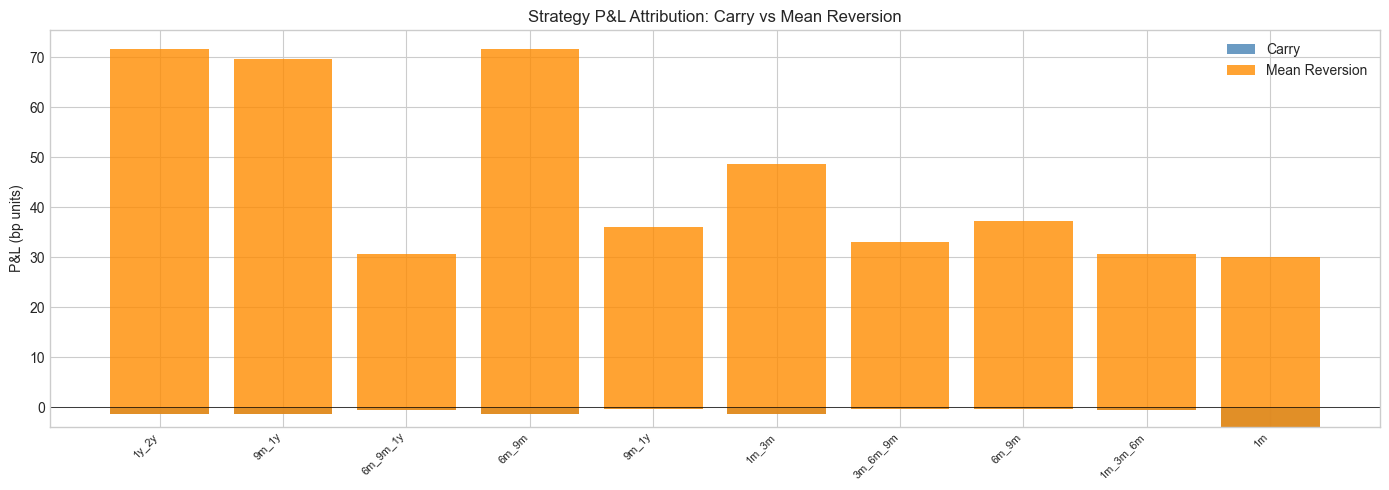

,strategy,total_pnl_bp,carry_bp,convergence_bp
0,xau|fwd_lease|1y_2y|ez1.5|xz0.5|mh20|cb0.04,71.6391,-1.3371,72.9762
1,xau|fwd_lease|9m_1y|ez1.5|xz0.5|mh63|cb0.04,69.7087,-1.3716,71.0803
2,xau|butterfly|6m_9m_1y|ez1.5|xz0.0|mh63|cb0.04,30.5832,-0.5785,31.1618
3,xau|fwd_lease|6m_9m|ez1.5|xz0.5|mh20|cb0.04,71.6391,-1.3371,72.9762
4,xau|slope|9m_1y|ez1.5|xz0.0|mh252|cb0.04,36.1006,-0.4628,36.5634
5,xag|slope|1m_3m|ez1.5|xz0.0|mh126|cb0.04,48.6813,-1.3142,49.9955
6,xau|butterfly|3m_6m_9m|ez1.5|xz0.5|mh252|cb0.04,33.0052,-0.4826,33.4878
7,xau|slope|6m_9m|ez1.5|xz0.5|mh126|cb0.04,37.1745,-0.3730,37.5475
8,xau|butterfly|1m_3m_6m|ez1.5|xz0.0|mh252|cb0.04,30.5832,-0.5785,31.1618
9,xm|xm_spread|1m|ez1.5|xz0.0|mh20|cb0.04,29.9880,-3.9041,33.8921



Performance by Rate Regime:

,mean,std,count,hit_rate
rate_regime,,,,
high,0.0213,0.1703,1246,0.3138
mid,0.0091,0.1691,979,0.2646
zirp,0.0121,0.1504,746,0.3150



Performance by Curve Regime:


,mean,std,count,hit_rate
curve_regime,,,,
flat,0.0126,0.2502,160,0.3500
normal,0.0143,0.1581,2715,0.2939
steep,0.0379,0.1823,96,0.3229


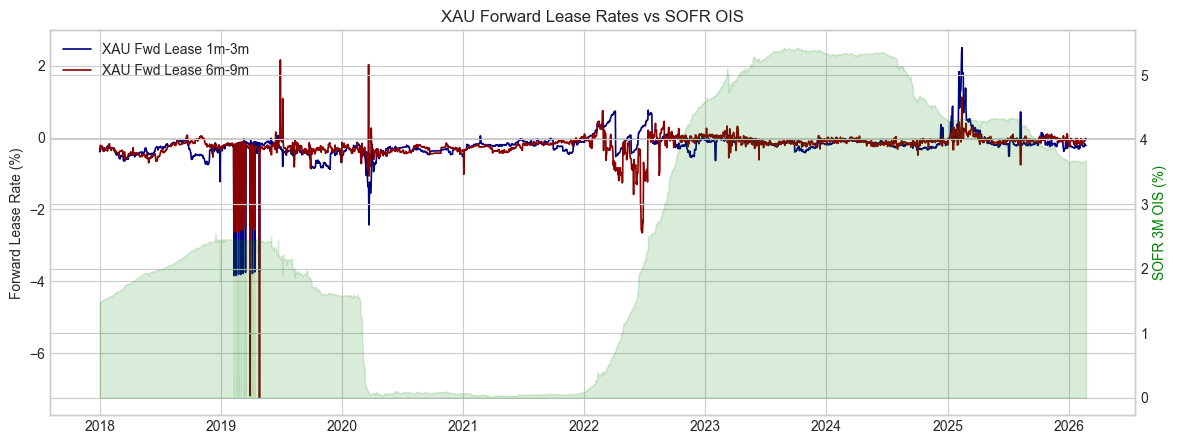

In [12]:
print('Section 7: Attribution & regime analysis...')

if len(keep) > 0 and len(selected) > 0:
    # Attribution from backtest metrics (carry vs mean-reversion)
    attr_rows = []
    for key in keep:
        parts = key.split('|')
        metal = parts[0]; ftype = parts[1]; bucket = parts[2]
        ez = float(key.split('ez')[1].split('|')[0])
        xz = float(key.split('xz')[1].split('|')[0])
        mh = int(float(key.split('mh')[1].split('|')[0]))
        cb = float(key.split('cb')[1])

        match = selected[
            (selected['metal'] == metal) &
            (selected['feature_type'] == ftype)
        ]
        if len(match) > 0:
            fcol = match.iloc[0]['feature_col']
            scol = match.iloc[0]['signal_col']
            r = backtest_single(df, scol, fcol,
                                entry_z=ez, exit_z=xz, stop_z=STOP_Z,
                                max_hold=mh, cost_bp=cb)
            tlog  = r['trade_log']
            total = r['metrics']['total_pnl_bp']
            # carry_bp: sum over trade-held days only, notional-weighted via pos[]
            carry_bp = float(tlog['carry_bp'].sum()) if len(tlog) > 0 else 0.0
            mrv_bp   = total - carry_bp
        else:
            total = pnl_filtered[key].sum()
            carry_bp = 0.0; mrv_bp = total

        attr_rows.append({
            'strategy': key, 'total_pnl_bp': total,
            'carry_bp': carry_bp, 'convergence_bp': mrv_bp
        })

    attr_df = pd.DataFrame(attr_rows)
    if SAVE_OUTPUTS:
        attr_df.to_csv('outputs/07_attribution.csv', index=False)

    # Carry vs MRV bar chart
    fig, ax = plt.subplots(figsize=(14, 5))
    x = range(len(attr_df))
    short_names = [k.split('|')[2][:10] for k in attr_df['strategy']]
    ax.bar(x, attr_df['carry_bp'], label='Carry', color='steelblue', alpha=0.8)
    ax.bar(x, attr_df['convergence_bp'], bottom=attr_df['carry_bp'],
           label='Mean Reversion', color='darkorange', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('P&L (bp units)')
    ax.set_title('Strategy P&L Attribution: Carry vs Mean Reversion')
    ax.legend()
    ax.axhline(0, color='black', linewidth=0.5)
    plt.tight_layout()
    if SAVE_OUTPUTS:
        plt.savefig('outputs/charts/11_carry_vs_mrv.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close()

    display(attr_df)
else:
    print("No strategies to attribute — skipping.")
    attr_df = pd.DataFrame(columns=['strategy','total_pnl_bp','carry_bp','convergence_bp'])

# Regime buckets
slope_z_cols = [c for c in df.columns if c.startswith('z_') and '_slope_' in c]
if slope_z_cols:
    df['curve_regime'] = np.where(
        df[slope_z_cols].median(axis=1) >  1.0, 'steep',
        np.where(df[slope_z_cols].median(axis=1) < -1.0, 'flat', 'normal'))

if len(portfolio_pnl) > 0:
    port_df = portfolio_pnl.to_frame('pnl_bp').join(
        df[['rate_regime','curve_regime']] if 'curve_regime' in df.columns
        else df[['rate_regime']])

    print("\nPerformance by Rate Regime:")
    display(port_df.groupby('rate_regime')['pnl_bp'].agg(
        ['mean','std','count',
         lambda x: (x > 0).mean()]).rename(
        columns={'<lambda_0>':'hit_rate'}))

    if 'curve_regime' in port_df.columns:
        print("\nPerformance by Curve Regime:")
        display(port_df.groupby('curve_regime')['pnl_bp'].agg(
            ['mean','std','count',
             lambda x: (x > 0).mean()]).rename(
            columns={'<lambda_0>':'hit_rate'}))

    # Forward lease rate history chart
    if 'xau_fwd_lease_1m_3m' in df.columns and 'xau_fwd_lease_6m_9m' in df.columns:
        fig, ax1 = plt.subplots(figsize=(14, 5))
        ax1.plot(df.index, df['xau_fwd_lease_1m_3m'],
                 label='XAU Fwd Lease 1m-3m', color='navy', linewidth=1.2)
        ax1.plot(df.index, df['xau_fwd_lease_6m_9m'],
                 label='XAU Fwd Lease 6m-9m', color='darkred', linewidth=1.2)
        ax1.set_ylabel('Forward Lease Rate (%)')
        ax1.legend(loc='upper left')
        ax2 = ax1.twinx()
        ax2.fill_between(df.index, df[FUNDING_COL], alpha=0.15, color='green')
        ax2.set_ylabel('SOFR 3M OIS (%)', color='green')
        ax1.set_title('XAU Forward Lease Rates vs SOFR OIS')
        if SAVE_OUTPUTS:
            plt.savefig('outputs/charts/12_fwd_lease_history.png',
                        dpi=150, bbox_inches='tight')
        plt.show(); plt.close()
else:
    port_df = pd.DataFrame()
    print("No portfolio P&L — skipping regime analysis.")

## 7b. Dollar P&L Conversion

Section 7b: Dollar P&L conversion...

IS (avg spot $1608/oz):
  Dollar Sharpe = 1.05
  Avg daily $/oz = 0.0019
  Max DD $/oz = -0.6752

OOS (avg spot $2696/oz):
  Dollar Sharpe = 2.09
  Avg daily $/oz = 0.0049
  Max DD $/oz = -0.3498

Full (avg spot $2027/oz):
  Dollar Sharpe = 1.50
  Avg daily $/oz = 0.0031
  Max DD $/oz = -0.6752

Note: IS dollar MaxDD is understated because XAU was ~$1800 during IS vs ~$2500-$5400 in OOS. Dollar risk is proportional to spot.


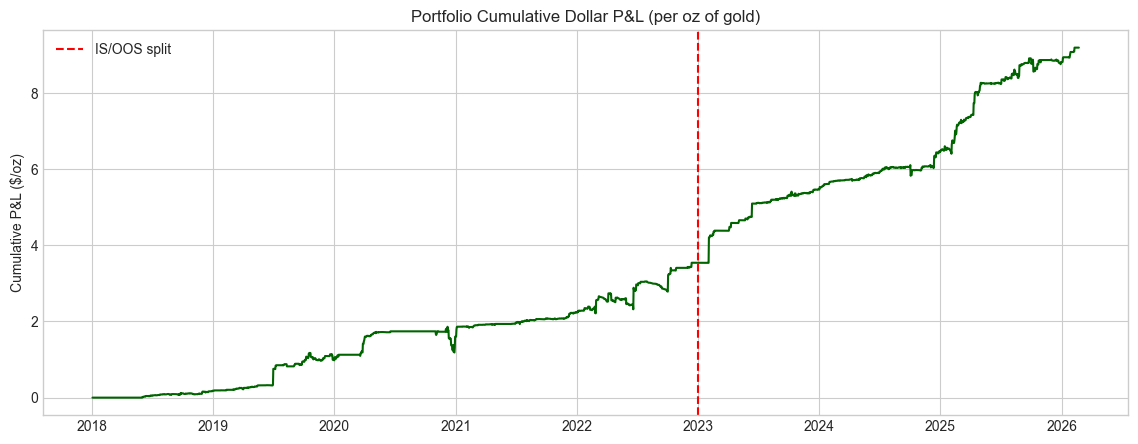

In [13]:
print('Section 7b: Dollar P&L conversion...')

if len(portfolio_pnl) > 0 and 'xauusd_spot' in df.columns:
    # Convert bp P&L to $/oz
    # P&L is in annualised % units x notional; spot converts to $/oz
    spot_aligned = df['xauusd_spot'].reindex(portfolio_pnl.index).ffill()
    portfolio_pnl_dollar = portfolio_pnl * spot_aligned / 10000.0

    # Dollar metrics
    for label, start, end in [('IS', IS_START, IS_END),
                               ('OOS', OOS_START, OOS_END),
                               ('Full', None, None)]:
        if start:
            s = portfolio_pnl_dollar.loc[start:end]
        else:
            s = portfolio_pnl_dollar
        if len(s) == 0:
            continue
        cum = s.cumsum()
        dd  = cum - cum.cummax()
        ann_ret = s.mean() * 252
        ann_vol = s.std() * np.sqrt(252)
        sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
        max_dd  = dd.min()
        avg_spot = spot_aligned.loc[s.index].mean()
        print(f"\n{label} (avg spot ${avg_spot:.0f}/oz):")
        print(f"  Dollar Sharpe = {sharpe:.2f}")
        print(f"  Avg daily $/oz = {s.mean():.4f}")
        print(f"  Max DD $/oz = {max_dd:.4f}")

    print("\nNote: IS dollar MaxDD is understated because XAU was ~$1800 "
          "during IS vs ~$2500-$5400 in OOS. Dollar risk is proportional to spot.")

    # Cumulative dollar P&L chart
    cum_dollar = portfolio_pnl_dollar.cumsum()
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(cum_dollar.index, cum_dollar.values, color='darkgreen', linewidth=1.5)
    ax.axvline(pd.Timestamp(OOS_START), color='red', linestyle='--', label='IS/OOS split')
    ax.set_ylabel('Cumulative P&L ($/oz)')
    ax.set_title('Portfolio Cumulative Dollar P&L (per oz of gold)')
    ax.legend()
    if SAVE_OUTPUTS:
        plt.savefig('outputs/charts/13_dollar_pnl.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close()

    if SAVE_OUTPUTS:
        portfolio_pnl_dollar.to_csv('outputs/07b_dollar_pnl.csv')
else:
    print("Skipping dollar conversion — no portfolio or spot data.")

# 8. Visualisations

Section 8: Generating charts...


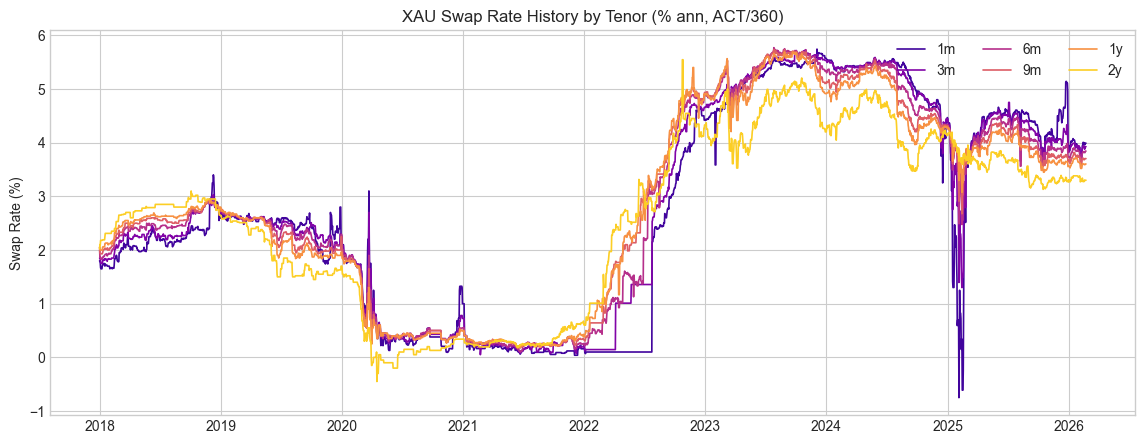

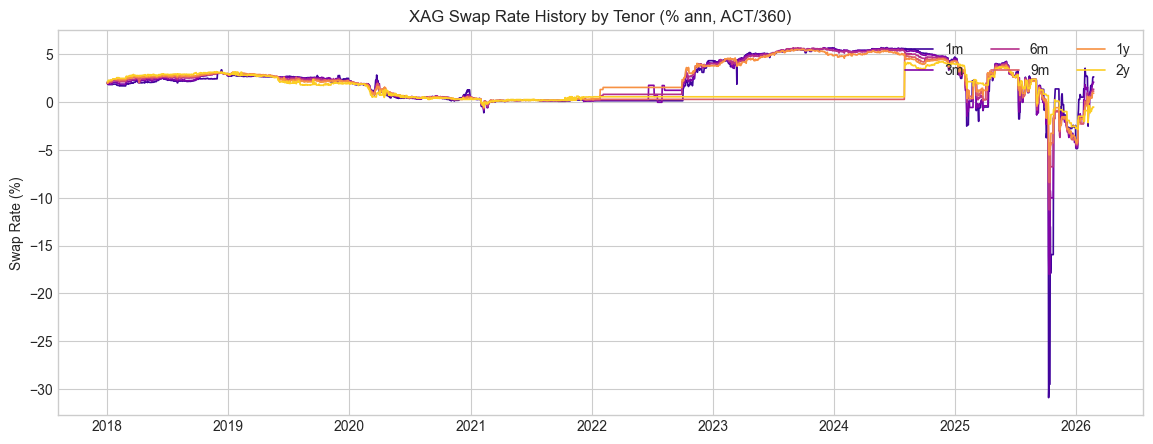

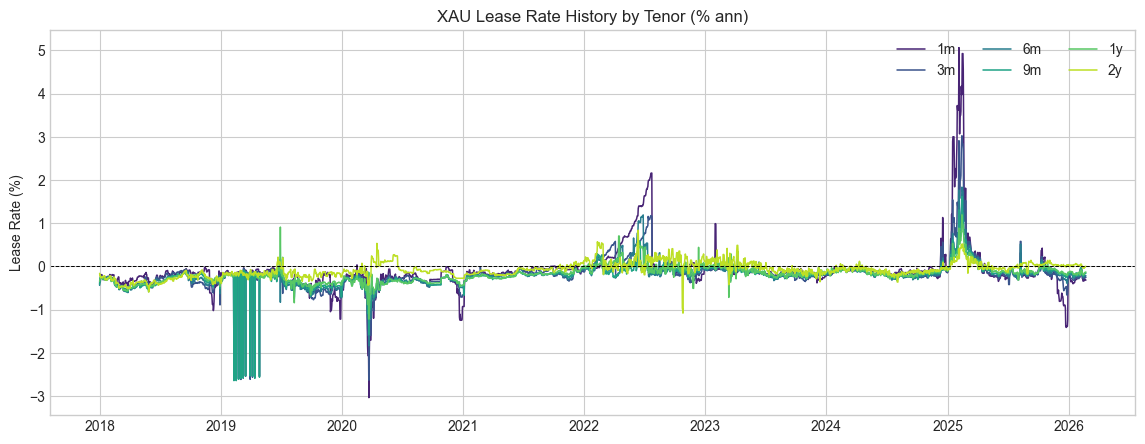

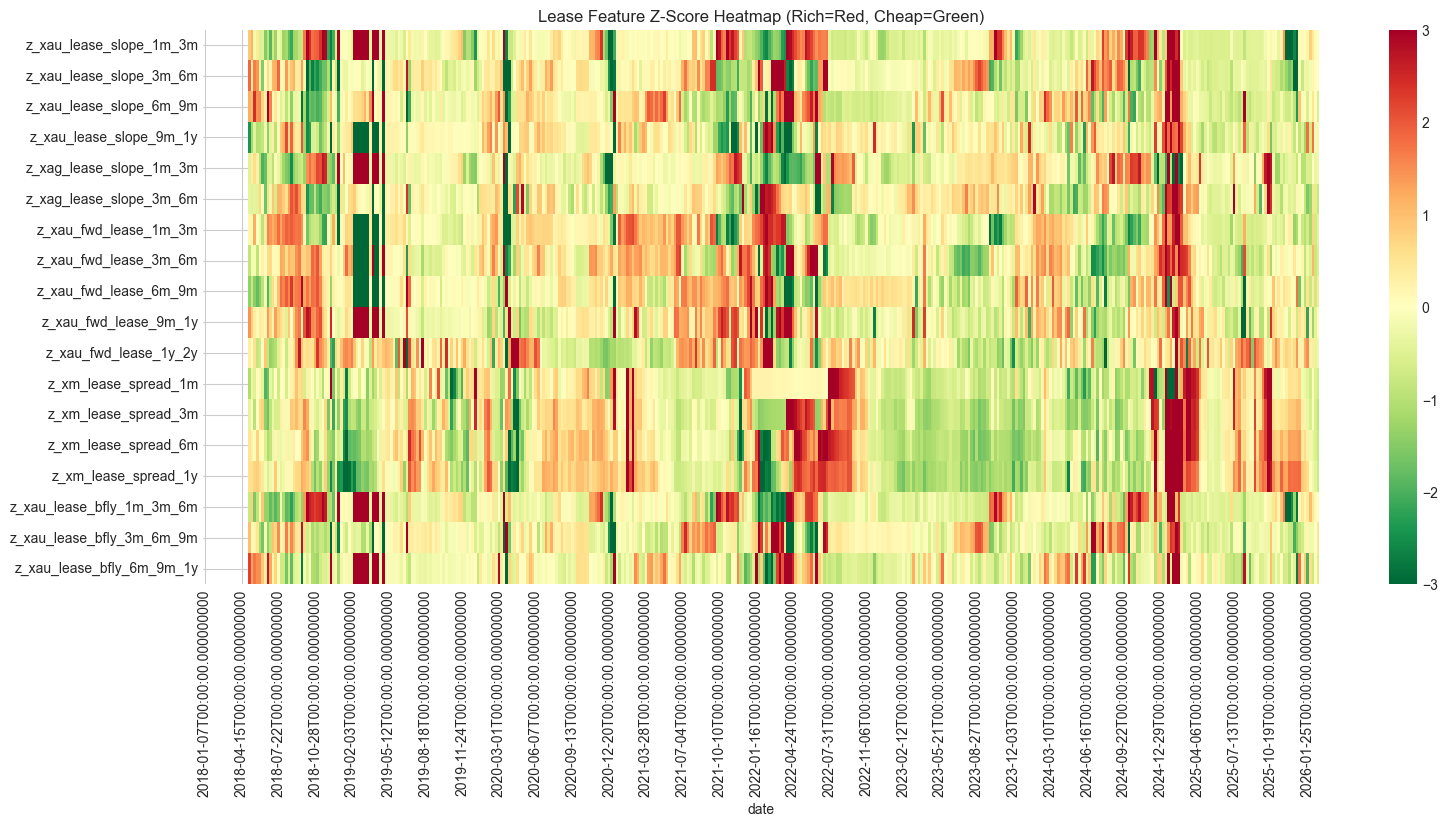

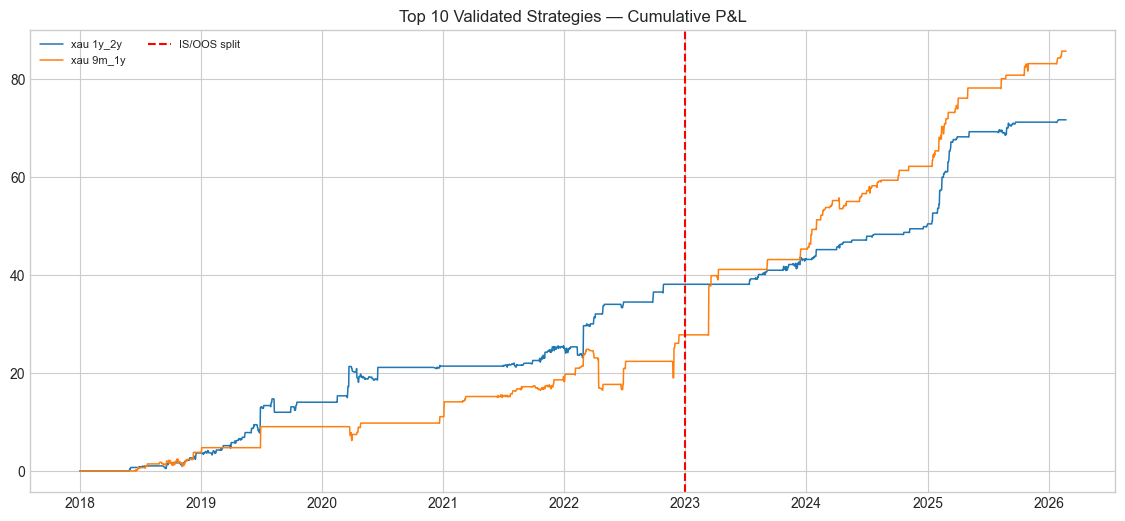

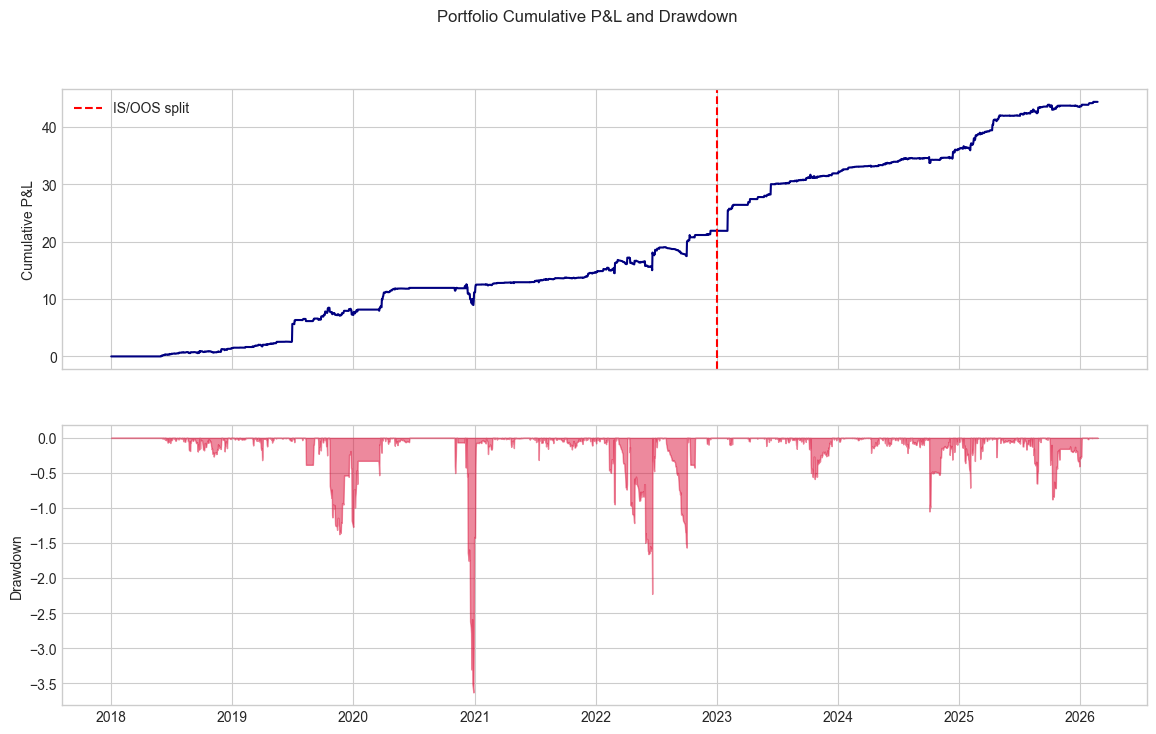

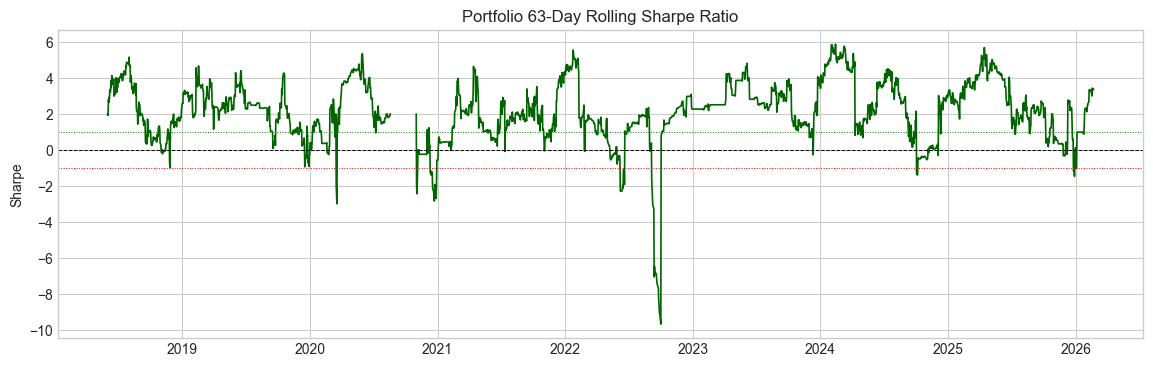

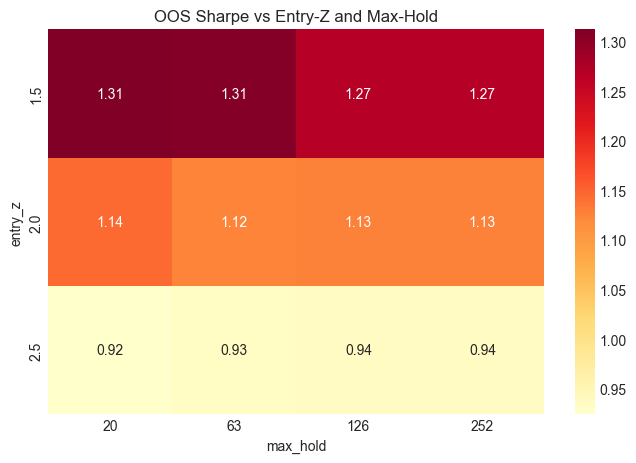

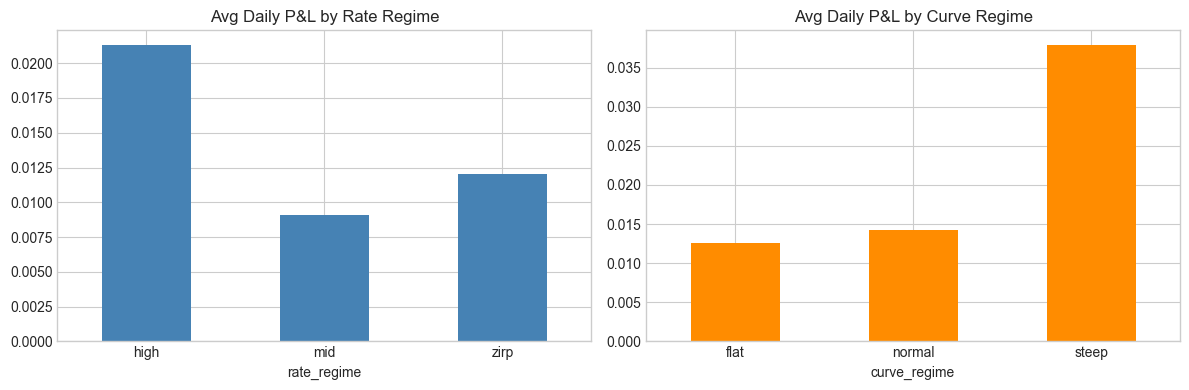

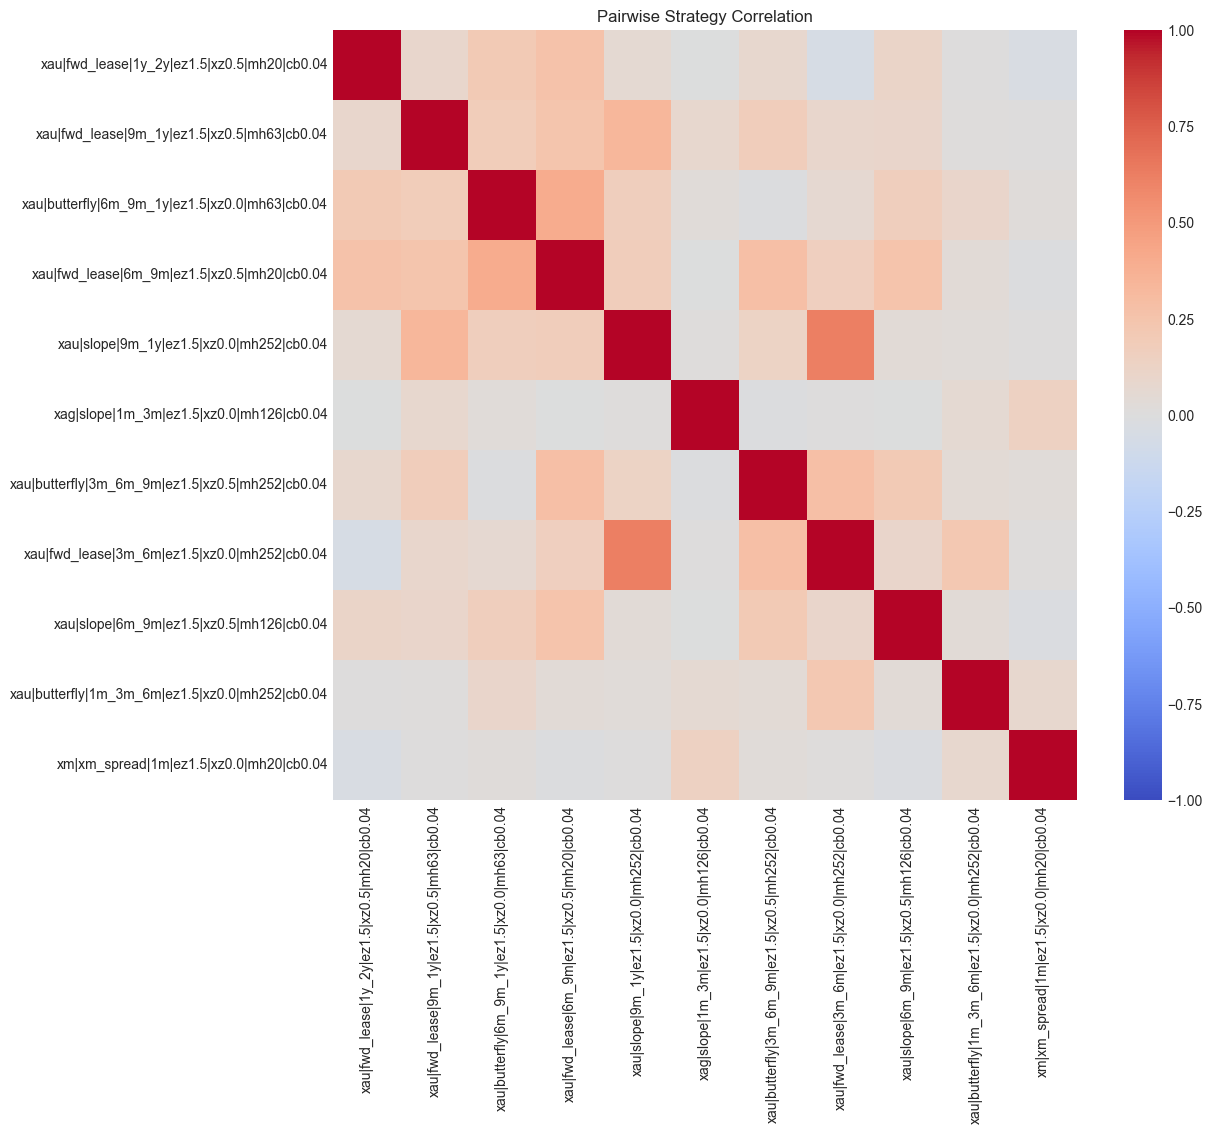

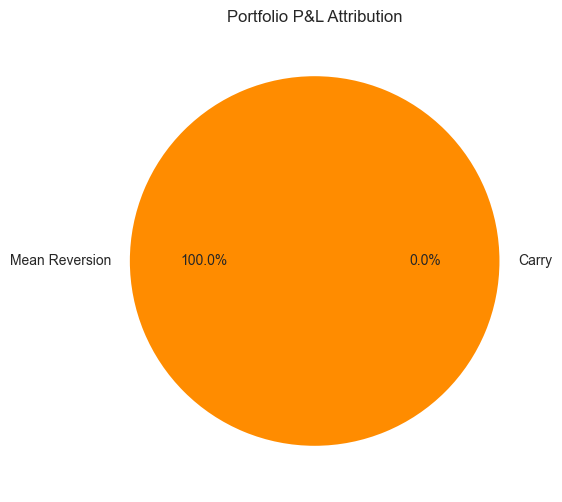

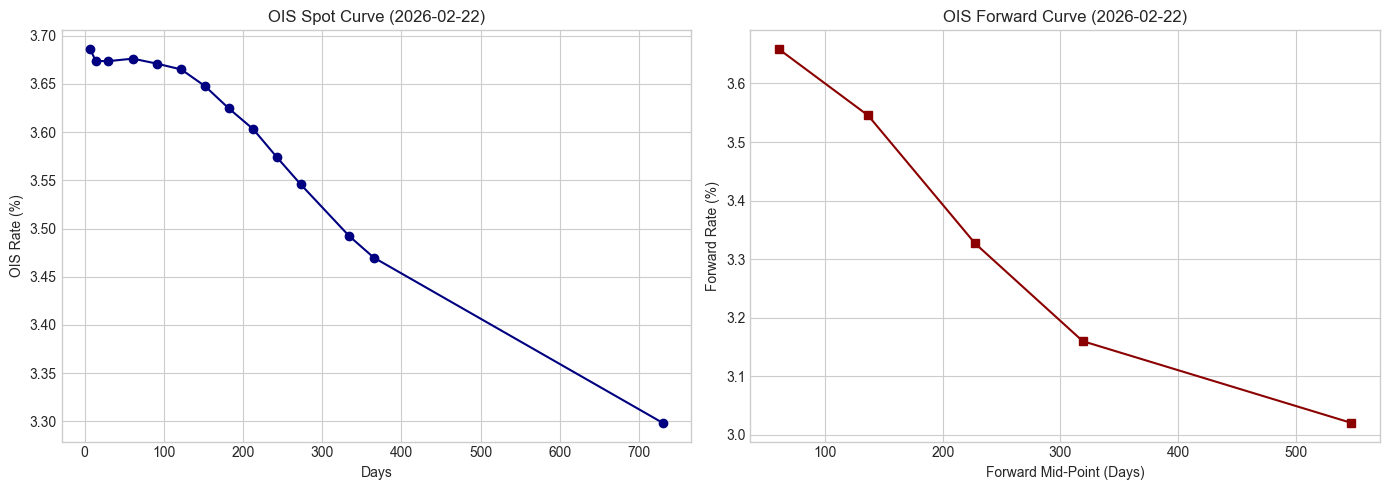

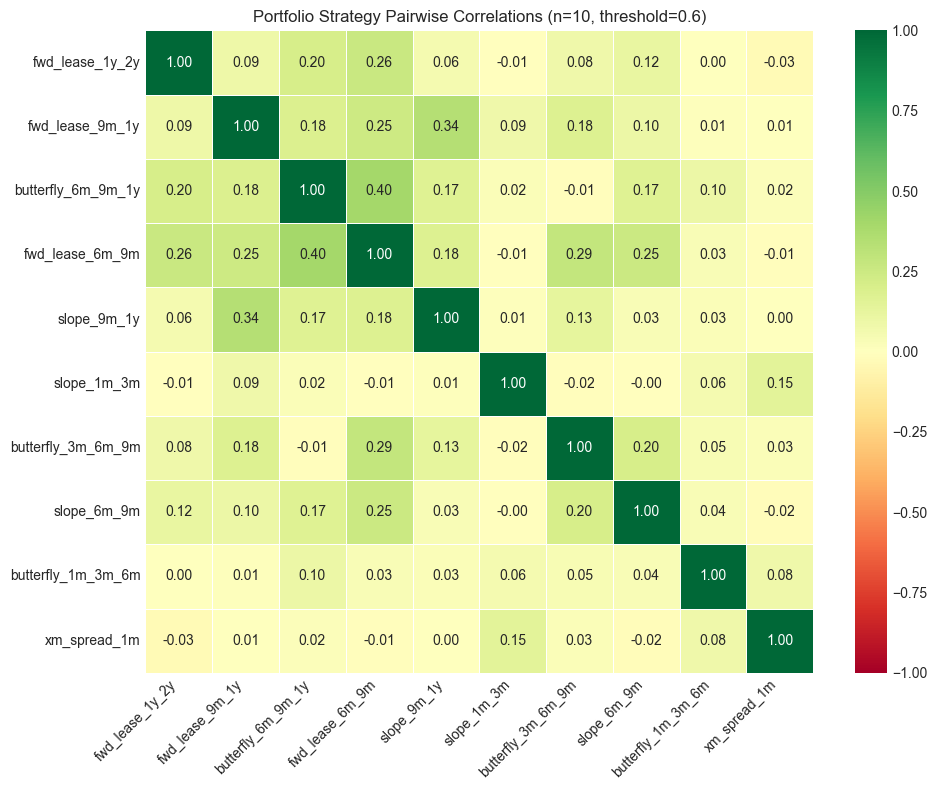

All charts generated.


In [14]:
print('Section 8: Generating charts...')

def savefig(name):
    if SAVE_OUTPUTS:
        plt.savefig(f'outputs/charts/{name}', dpi=150, bbox_inches='tight')
    plt.show(); plt.close()

# Chart 1: Swap curve history per metal
for metal in METALS:
    fig, ax = plt.subplots(figsize=(14, 5))
    colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(TENORS)))
    for t, col in zip(TENORS, colors):
        ax.plot(df.index, df[f'{metal}_swap_{t}'], label=t, color=col, linewidth=1.2)
    ax.set_title(f'{metal.upper()} Swap Rate History by Tenor (% ann, ACT/360)')
    ax.set_ylabel('Swap Rate (%)')
    ax.legend(loc='upper right', ncol=3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    savefig(f'01_curve_history_{metal}.png')

# Chart 2: Lease rate history (XAU)
fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(TENORS)))
for t, col in zip(TENORS, colors):
    if f'xau_lease_{t}' in df.columns:
        ax.plot(df.index, df[f'xau_lease_{t}'], label=t, color=col, linewidth=1.1)
ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax.set_title('XAU Lease Rate History by Tenor (% ann)')
ax.set_ylabel('Lease Rate (%)')
ax.legend(loc='upper right', ncol=3)
savefig('02_lease_history_xau.png')

# Chart 3: Z-score heatmap for lease features
lease_zcols = [f'z_{c}' for c in feature_cols if c in df.columns and f'z_{c}' in df.columns]
if lease_zcols:
    z_weekly = df[lease_zcols].resample('W').last().T
    fig, ax = plt.subplots(figsize=(18, max(4, len(lease_zcols) * 0.4)))
    sns.heatmap(z_weekly, cmap='RdYlGn_r', center=0,
                vmin=-3, vmax=3, ax=ax,
                xticklabels=max(1, z_weekly.shape[1]//30), yticklabels=True)
    ax.set_title('Lease Feature Z-Score Heatmap (Rich=Red, Cheap=Green)')
    savefig('03_zscore_heatmap_lease.png')

# Chart 4: Top validated strategies cumulative pnl
if len(top20) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    for _, row in top20.head(10).iterrows():
        key = (f"{row['metal']}|{row['feature_type']}|"
               f"{row['bucket']}|ez{row['entry_z']}|"
               f"xz{row['exit_z']}|mh{row['max_hold']}|"
               f"cb{row['cost_bp']}")
        if key in selected_daily:
            cum = selected_daily[key].cumsum()
            ax.plot(cum.index, cum.values,
                    label=f"{row['metal']} {row['bucket']}", linewidth=1.1)
    ax.axvline(pd.Timestamp(OOS_START), color='red', linestyle='--', label='IS/OOS split')
    ax.set_title('Top 10 Validated Strategies \u2014 Cumulative P&L')
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    savefig('04_cum_pnl_best_strategies.png')

# Chart 5: Portfolio cumulative pnl with drawdown
if len(portfolio_cum) > 0:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    ax1.plot(portfolio_cum.index, portfolio_cum.values, color='navy', linewidth=1.5)
    ax1.axvline(pd.Timestamp(OOS_START), color='red', linestyle='--', label='IS/OOS split')
    ax1.set_ylabel('Cumulative P&L'); ax1.legend()
    dd_series = portfolio_cum - portfolio_cum.cummax()
    ax2.fill_between(dd_series.index, dd_series.values, 0, color='crimson', alpha=0.5)
    ax2.set_ylabel('Drawdown')
    plt.suptitle('Portfolio Cumulative P&L and Drawdown')
    savefig('05_portfolio_cum_pnl.png')

    # Chart 6: Rolling Sharpe
    roll_sharpe = (portfolio_pnl.rolling(RISK_PARITY_WINDOW).mean() * 252 /
                   (portfolio_pnl.rolling(RISK_PARITY_WINDOW).std() * np.sqrt(252)))
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(roll_sharpe.index, roll_sharpe.values, color='darkgreen', linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.axhline(1, color='green', linewidth=0.7, linestyle=':')
    ax.axhline(-1, color='red', linewidth=0.7, linestyle=':')
    ax.set_title('Portfolio 63-Day Rolling Sharpe Ratio')
    ax.set_ylabel('Sharpe')
    savefig('06_rolling_sharpe.png')

# Chart 7: Parameter sensitivity
if len(grid_df) > 0:
    pivot = (grid_df[grid_df['validated']]
             .groupby(['entry_z','max_hold'])['oos_sharpe']
             .mean().unstack())
    if not pivot.empty:
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
        ax.set_title('OOS Sharpe vs Entry-Z and Max-Hold')
        savefig('07_param_sensitivity.png')

# Chart 8: Regime performance
if len(portfolio_pnl) > 0 and len(port_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    port_df.groupby('rate_regime')['pnl_bp'].mean().plot(
        kind='bar', ax=axes[0], color='steelblue', rot=0)
    axes[0].set_title('Avg Daily P&L by Rate Regime')
    axes[0].axhline(0, color='black', linewidth=0.7)
    if 'curve_regime' in port_df.columns:
        port_df.groupby('curve_regime')['pnl_bp'].mean().plot(
            kind='bar', ax=axes[1], color='darkorange', rot=0)
        axes[1].set_title('Avg Daily P&L by Curve Regime')
        axes[1].axhline(0, color='black', linewidth=0.7)
    plt.tight_layout()
    savefig('08_regime_performance.png')

# Chart 9: Correlation matrix
if len(corr) > 0:
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax,
                xticklabels=True, yticklabels=True, annot=False)
    ax.set_title('Pairwise Strategy Correlation')
    savefig('09_correlation_matrix.png')

# Chart 10: Attribution pie
if not attr_df.empty:
    tc = attr_df['carry_bp'].sum()
    tm = attr_df['convergence_bp'].sum()
    if tc + tm != 0:
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.pie([max(tc,0), max(tm,0)],
               labels=['Carry', 'Mean Reversion'],
               autopct='%1.1f%%', colors=['steelblue','darkorange'])
        ax.set_title('Portfolio P&L Attribution')
        savefig('10_attribution_pie.png')

# Chart 11: OIS yield curve snapshot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
last_row = df.iloc[-1]
spot_rates = [last_row[t] for t in OIS_TENORS]
days = [OIS_DAYS[t] for t in OIS_TENORS]
ax1.plot(days, spot_rates, 'o-', color='navy')
ax1.set_xlabel('Days'); ax1.set_ylabel('OIS Rate (%)')
ax1.set_title(f'OIS Spot Curve ({df.index[-1].date()})')
# Forward curve
fwd_mids = [(d1+d2)/2 for _,_,d1,d2 in FORWARD_SEGMENTS]
fwd_rates = [last_row.get(f'ois_fwd_{c1.replace("sofr_ois_","")}_'
              f'{c2.replace("sofr_ois_","")}', np.nan)
              for c1,c2,_,_ in FORWARD_SEGMENTS]
ax2.plot(fwd_mids, fwd_rates, 's-', color='darkred')
ax2.set_xlabel('Forward Mid-Point (Days)'); ax2.set_ylabel('Forward Rate (%)')
ax2.set_title(f'OIS Forward Curve ({df.index[-1].date()})')
plt.tight_layout()
savefig('14_ois_curves.png')

# Chart: Portfolio strategy correlation heatmap
if len(keep) > 1 and len(candidate_daily) > 0:
    pnl_plot = pd.DataFrame({
        k.split('|')[1] + '_' + k.split('|')[2]: candidate_daily[k]
        for k in keep
    }).fillna(0)
    corr_plot = pnl_plot.corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        corr_plot,
        annot=True, fmt='.2f',
        cmap='RdYlGn', center=0,
        vmin=-1, vmax=1,
        ax=ax, linewidths=0.5
    )
    ax.set_title(
        f'Portfolio Strategy Pairwise Correlations '
        f'(n={len(keep)}, threshold={CORR_THRESHOLD})'
    )
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    savefig('10_portfolio_corr_heatmap.png')

print("All charts generated.")

# 9. Summary Report

In [15]:
print('Section 9: Generating summary report...')

report_lines = [
    "=" * 65,
    "GOLD/SILVER LEASE CURVE CARRY SYSTEM \u2014 RESEARCH SUMMARY",
    "=" * 65,
    f"Data      : {df.index[0].date()} to {df.index[-1].date()}, {len(df)} rows",
    f"Features  : {len(feature_cols)} lease rate features",
    (f"Strategies: {len(grid_df)} combos tested, "
     f"{grid_df['validated'].sum()} validated, "
     f"{len(keep)} in portfolio (post corr-filter, "
     f"threshold={CORR_THRESHOLD})"),
    "",
    "ACT/360. P&L in annualised % units (lease rate differential).",
    "",
    "--- Top 5 Validated Strategies (by OOS Sharpe) ---"
]
for _, r in top20.head(5).iterrows():
    report_lines.append(
        f"  {r['metal']:4s} | {r['feature_type']:10s} | "
        f"{r['bucket']:12s} | ez={r['entry_z']} mh={int(r['max_hold'])} | "
        f"IS_SR={r['is_sharpe']:.2f} OOS_SR={r['oos_sharpe']:.2f}")

report_lines += [
    "",
    f"Portfolio IS  : Sharpe={m_port_is['sharpe']:.2f}  MaxDD={m_port_is['maxdd']:.4f}",
    f"Portfolio OOS : Sharpe={m_port_oos['sharpe']:.2f}  MaxDD={m_port_oos['maxdd']:.4f}",
    "",
    "--- Portfolio Strategy List ---"
] + [
    f"  {k}" for k in keep
] + [
    "",
    "--- Attribution ---",
    f"  Carry          : {attr_df['carry_bp'].sum():.4f}",
    f"  Mean Reversion : {attr_df['convergence_bp'].sum():.4f}",
    "",
    "--- Regime Distribution ---",
]
for regime in ['zirp','mid','high']:
    cnt = (df['rate_regime'] == regime).sum()
    report_lines.append(f"  {regime}: {cnt} rows ({cnt/len(df)*100:.1f}%)")

report_lines += [
    "",
    "--- BQNT Production Gaps ---",
    "  \u2022 Bid/ask per tenor for realistic costs",
    "  \u2022 COMEX futures + EFP basis for execution",
    "",
    "--- OIS Curve Quality ---",
    f"  Non-monotone days (any segment) : {len(NON_MONO_DATES)}",
    f"  Non-monotone days (1y\u21922y only): "
    f"{len(NON_MONO_DATES_BY_SEG.get('1y_2y', set()))}",
    f"  Monotonicity gate active        : {USE_MONO_GATE}",
    "  Period affected                 : 2018-12 to 2021-07 (ZIRP)",
    "=" * 65
]

report = "\n".join(report_lines)
print(report)
if SAVE_OUTPUTS:
    with open('outputs/09_summary_report.txt', 'w') as f:
        f.write(report)

Section 9: Generating summary report...
GOLD/SILVER LEASE CURVE CARRY SYSTEM — RESEARCH SUMMARY
Data      : 2018-01-01 to 2026-02-22, 2971 rows
Features  : 18 lease rate features
Strategies: 1296 combos tested, 459 validated, 10 in portfolio (post corr-filter, threshold=0.6)

ACT/360. P&L in annualised % units (lease rate differential).

--- Top 5 Validated Strategies (by OOS Sharpe) ---
  xau  | fwd_lease  | 1y_2y        | ez=1.5 mh=20 | IS_SR=1.15 OOS_SR=2.20
  xau  | fwd_lease  | 1y_2y        | ez=1.5 mh=252 | IS_SR=1.12 OOS_SR=2.12
  xau  | fwd_lease  | 1y_2y        | ez=1.5 mh=126 | IS_SR=1.12 OOS_SR=2.12
  xau  | fwd_lease  | 1y_2y        | ez=1.5 mh=63 | IS_SR=1.11 OOS_SR=2.12
  xau  | fwd_lease  | 1y_2y        | ez=1.5 mh=20 | IS_SR=1.01 OOS_SR=2.06

Portfolio IS  : Sharpe=1.12  MaxDD=-3.6304
Portfolio OOS : Sharpe=1.99  MaxDD=-1.0497

--- Portfolio Strategy List ---
  xau|fwd_lease|1y_2y|ez1.5|xz0.5|mh20|cb0.04
  xau|fwd_lease|9m_1y|ez1.5|xz0.5|mh63|cb0.04
  xau|butterfly|6m_9